# HW1 — Credential Stuffing Attack Detection
**Course:** 3917 — AI Techniques for Malware Detection
**Semester:** 2 / 2026

| Student | ID | Email |
|---|---|---|
| Amit Cohen | 318556016 | amit.cohen04@post.runi.ac.il |
| Sagi Levhar | 206590457 | sagi.levhar@post.runi.ac.il |

**AI tools used:** Claude (Anthropic) — see §AI Disclosure at the bottom.

In [1]:
# ── Global imports and reproducibility ──────────────────────────────────────
# We set the seed at the very top so every random operation in the notebook
# (train/test splits, sampling, etc.) gives the same result each run.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import random
from scipy import stats as sp_stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Pull in all our helper functions from helpers.py.
# Keeping reusable code there means the notebook stays focused on the
# analysis logic rather than utility boilerplate.
from helpers import *

# Make all plots look clean and consistent throughout the notebook.
sns.set_theme(style='whitegrid', font_scale=0.9)
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 4)})
print("Setup complete — ready to run.")


Setup complete — ready to run.


**Observation — environment setup:**
All imports loaded successfully. `RANDOM_STATE = 42` is set globally so that
every random operation (sampling, train/test splits) will produce the same
result on any machine. The colour constants `COLOR_MAL` and `COLOR_OK` are
imported from `helpers.py` and will be used consistently in every plot.

---
## Part A — Exploratory Data Analysis (15 pts)
Getting to know the data before we build anything. The goal here is to
understand the shape, completeness, and statistical character of the dataset
so that every decision we make later (threshold choice, feature design,
missing-value strategy) is grounded in evidence rather than guesswork.


### A.1 — Data Overview (5 pts)


In [2]:
# ============================================================
# A1_load — read the dataset and preserve row order
# ============================================================
# We keep the original row order and all original columns in df so the submitted
# CSV is exactly the dataset with labels appended. Time-specific analyses
# sort/resample by timestamp locally instead of changing the master DataFrame.
df = pd.read_csv('assignment.csv')

print('Shape:', df.shape)
print()
print('Column types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Missing %:')
print((df.isnull().mean() * 100).round(2))


Shape: (530816, 10)

Column types:
Unnamed: 0          int64
epoch               int64
tool_id            object
network_type       object
email_hash         object
status_code         int64
country            object
hashed_ip          object
risk_indication      bool
network_id         object
dtype: object

Missing values per column:
Unnamed: 0              0
epoch                   0
tool_id                 0
network_type       411792
email_hash              0
status_code             0
country                19
hashed_ip               0
risk_indication         0
network_id              0
dtype: int64

Missing %:
Unnamed: 0          0.00
epoch               0.00
tool_id             0.00
network_type       77.58
email_hash          0.00
status_code         0.00
country             0.00
hashed_ip           0.00
risk_indication     0.00
network_id          0.00
dtype: float64


**Observation — shape and missingness:**
The dataset has **530,816 rows and 9 real columns**, matching the assignment's
~530K-login-attempt description. The only substantial missingness is
`network_type`: **411,792 rows / 77.58 %** are null. That matches the PDF warning,
so we treat missing network type as an explicit `"unknown"` category in B.4
instead of dropping rows.

There are also **19 missing country values**, which is negligible at this scale
(~0.004 % of rows). We leave those as missing for descriptive country plots and
rely on aggregate features/labels that do not require country to be present.


In [3]:
# ============================================================
# A1_basic_stats — summary counts rendered as a tidy table
# ============================================================
# These five counts give us a quick sense of dataset diversity before we
# dive into distributions. High unique-IP count with low unique-email count
# would hint at distributed bots targeting the same accounts; the reverse
# (few IPs, many emails) is the classic stuffing pattern.
basic_stats = pd.Series({
    'unique IPs':       df['hashed_ip'].nunique(),
    'unique emails':    df['email_hash'].nunique(),
    'unique tools':     df['tool_id'].nunique(),
    'unique networks':  df['network_id'].nunique(),
    'unique countries': df['country'].nunique(),
}).to_frame('count')
basic_stats


,count
unique IPs,91313
unique emails,139406
unique tools,194
unique networks,5204
unique countries,195


**Observation — entity counts:**
The data contains **91,313 unique IPs** and **139,406 unique email hashes**.
That combination is suspicious: many IPs are clearly touching more than one
account, and Part A.3/B.1 show the long tail where a small number of IPs try
dozens to thousands of distinct emails.

The dataset also contains **194 tools**, **5,204 networks**, and **195 countries**,
so detection cannot rely on one simple field. We need IP/email/tool/network
features together, and we should treat `risk_indication` as a noisy signal to
audit in Part C rather than as ground truth.


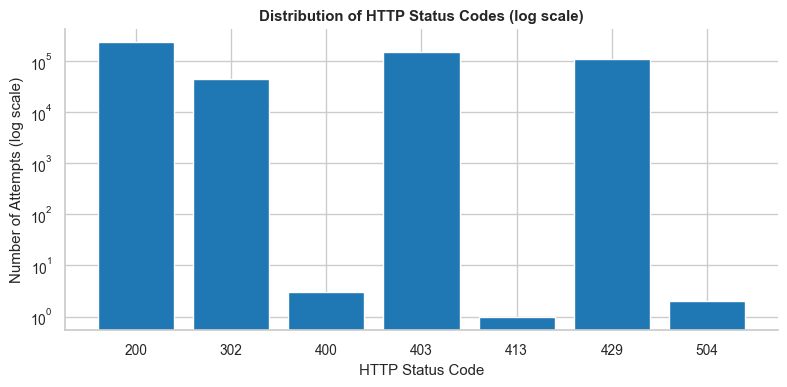

Status code counts:
status_code
200    229674
302     44370
400         3
403    148508
413         1
429    108258
504         2
Name: count, dtype: int64

Total rows: 530,816


In [4]:
# ============================================================
# A1_status_dist — bar chart of status_code counts (log-y scale)
# (see markdown cell directly below for the written answer — A.1 Q3)
# ============================================================
# Log-y is essential here because one or two status codes dominate and the
# others would be invisible on a linear scale.
fig, ax = plt.subplots(figsize=(8, 4))

status_counts = df['status_code'].value_counts().sort_index()
ax.bar(status_counts.index.astype(str), status_counts.values,
       color=COLOR_OK, edgecolor='white')
ax.set_yscale('log')
ax.set_title('Distribution of HTTP Status Codes (log scale)', fontweight='bold')
ax.set_xlabel('HTTP Status Code')
ax.set_ylabel('Number of Attempts (log scale)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
savefig('A1_status_codes')
plt.show()

print("Status code counts:")
print(status_counts)
print()
print(f"Total rows: {len(df):,}")


**Answer to A.1 Q3 — what each status code likely represents:**

The actual distribution is dominated by four statuses: **200 = 229,674**,
**403 = 148,508**, **429 = 108,258**, and **302 = 44,370**. The rare statuses
(400, 413, 504) appear only six times total and should not drive any rule.

* **200 OK** → a successful login according to the assignment definition. This
  is the most urgent outcome because a malicious 200 means likely account takeover.

* **302 Found / Redirect** → usually a normal web-login redirect flow. In this
  data it looks especially legitimate because only **0.4 %** of 302 responses
  are flagged by the vendor; this supports using 302-heavy behaviour as a
  legitimacy signal rather than blindly treating every non-200 as suspicious.

* **403 Forbidden** → the server/WAF actively refused the request, often because
  the IP, headers, fingerprint, or request pattern looked abusive.

* **429 Too Many Requests** → the rate limiter fired. This is a strong automation
  clue because a human usually backs off, while a bot keeps hitting the service.

* **400 / 413 / 504** → rare malformed-request or server-side edge cases. Their
  counts are too tiny to justify a dedicated rule, but they are still retained
  in the status entropy calculation.

**Observation on balance:** The response mix already hints at attack traffic:
there are large volumes of 403 and 429 responses, not just ordinary 200/302
login flows.


### A.2 — Temporal Analysis (5 pts)


In [5]:
# ============================================================
# A2_time_range — parse timestamps and print the exact span
# Answer to A.2 Q1: printed below
# ============================================================
# We store the human-readable timestamp as 'ts' for plotting convenience
# but keep 'epoch' (milliseconds since Unix epoch) for numerical calculations.
df['ts'] = pd.to_datetime(df['epoch'], unit='ms')

print("Answer to A.2 Q1 — time range:")
print(f"  From : {df['ts'].min()}")
print(f"  To   : {df['ts'].max()}")
print(f"  Span : {df['ts'].max() - df['ts'].min()}")


Answer to A.2 Q1 — time range:
  From : 2020-11-04 04:00:00.005000
  To   : 2020-11-04 04:59:59.990000
  Span : 0 days 00:59:59.985000


**Answer to A.2 Q1 — exact time range:**
The capture window runs from **2020-11-04 04:00:00.005** to
**2020-11-04 04:59:59.990**, a span of **59 minutes 59.985 seconds**.

Because the entire dataset fits into essentially one hour, rate features are
meaningful: an IP with hundreds or thousands of attempts is not simply active
across days, it is acting at machine speed inside a tight observation window.


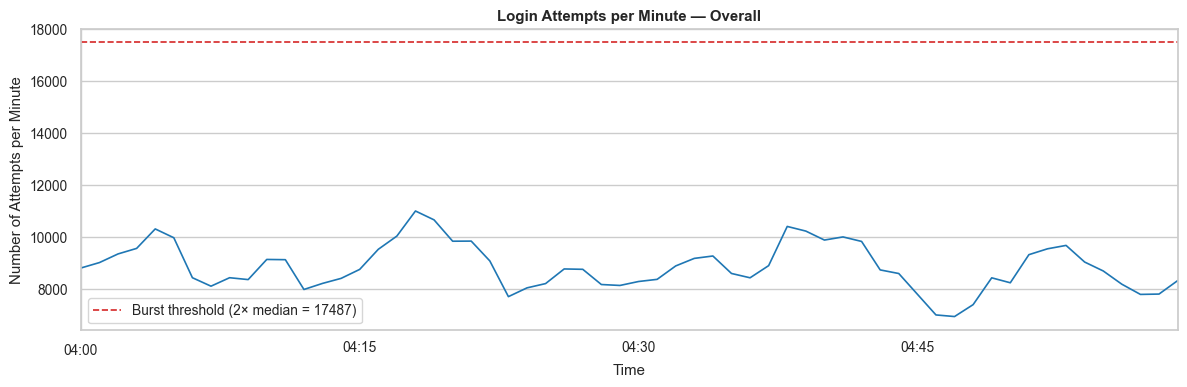

Median 1-min rate: 8744
Burst threshold (2x median): 17487
Minute-bins above burst threshold: 0 of 60


In [6]:
# ============================================================
# A2_per_minute — overall login volume per minute as a line plot
# Answer to A.2 Q2: see markdown below
# ============================================================
# We resample to 1-minute bins so we can see attack bursts without the noise
# of per-second granularity. A bin >2× the median rate is a burst.
per_min = df.set_index('ts').sort_index().resample('1min').size()
median_rate = per_min.median()
burst_threshold = 2 * median_rate

fig, ax = plt.subplots(figsize=(12, 4))
per_min.plot(ax=ax, color=COLOR_OK, linewidth=1.2)
ax.axhline(burst_threshold, color=COLOR_MAL, linestyle='--', linewidth=1.2,
           label=f'Burst threshold (2× median = {burst_threshold:.0f})')
ax.set_title('Login Attempts per Minute — Overall', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Number of Attempts per Minute')
ax.legend()
plt.tight_layout()
savefig('A2_per_minute')
plt.show()

n_burst_bins = (per_min > burst_threshold).sum()
print(f"Median 1-min rate: {median_rate:.0f}")
print(f"Burst threshold (2x median): {burst_threshold:.0f}")
print(f"Minute-bins above burst threshold: {n_burst_bins} of {len(per_min)}")


**Answer to A.2 Q2 — bursts and patterns:**
The median load is **8,744 attempts per minute**, so the 2× burst threshold is
**17,487 attempts per minute**. No minute exceeds that threshold (**0 of 60**).

That means this is not a single obvious spike; it is a sustained high-volume
login event across the full hour. For detection, that makes per-IP behaviour
more important than global traffic volume: the overall service is constantly
busy, so the attacker has to be separated by fan-out, tool choice, rate, network
type, and entropy rather than by one dramatic time burst.


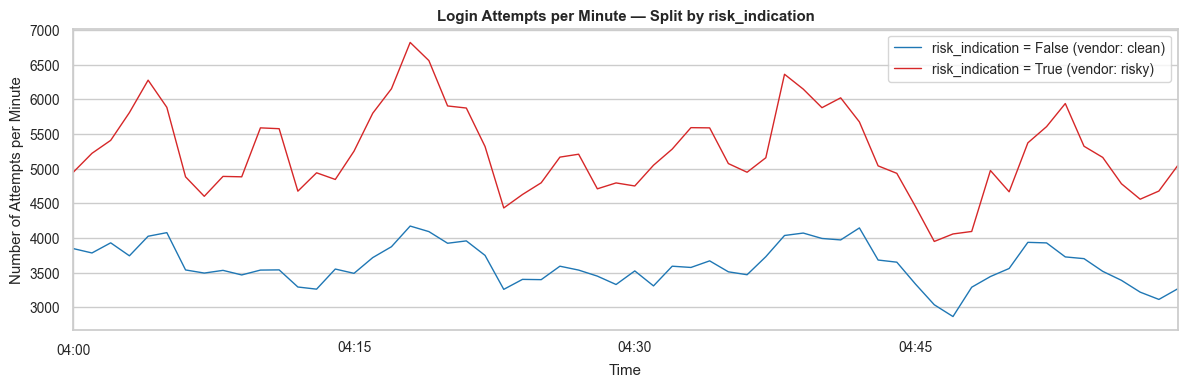

In [7]:
# ============================================================
# A2_per_minute_split — same plot, split by risk_indication
# Answer to A.2 Q3: see markdown below
# ============================================================
# Splitting by the vendor's risk_indication lets us see whether bursts
# are flagged or not. But we must interpret this cautiously — risk_indication
# is noisy (we will measure this in Part C).
per_min_by_risk = (
    df.set_index('ts')
      .sort_index()
      .groupby('risk_indication')
      .resample('1min')
      .size()
      .unstack(level=0)
      .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 4))
if False in per_min_by_risk.columns:
    per_min_by_risk[False].plot(ax=ax, color=COLOR_OK, linewidth=1.0,
                                 label='risk_indication = False (vendor: clean)')
if True in per_min_by_risk.columns:
    per_min_by_risk[True].plot(ax=ax, color=COLOR_MAL, linewidth=1.0,
                                label='risk_indication = True (vendor: risky)')
ax.set_title('Login Attempts per Minute — Split by risk_indication', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Number of Attempts per Minute')
ax.legend()
plt.tight_layout()
savefig('A2_per_minute_split')
plt.show()


**Answer to A.2 Q3 — split by risk_indication:**
This plot shows the minute-by-minute breakdown of attempts that the *vendor*
flagged as risky vs clean. If the risky series mirrors every burst, the vendor
label is doing a reasonable job of catching attack waves. However, we should
be cautious: **`risk_indication` is noisy**. In Part C we will measure that
the vendor flag fires on roughly 59 % of attempts — far too high to be a
reliable ground truth (no plausible attack would account for 59 % of all
traffic). A spike in the "risky" line just means the vendor's system *thought*
it was risky at that moment; we will revisit whether that belief is calibrated
when we build our own heuristics.


### A.3 — Entity Analysis (5 pts)


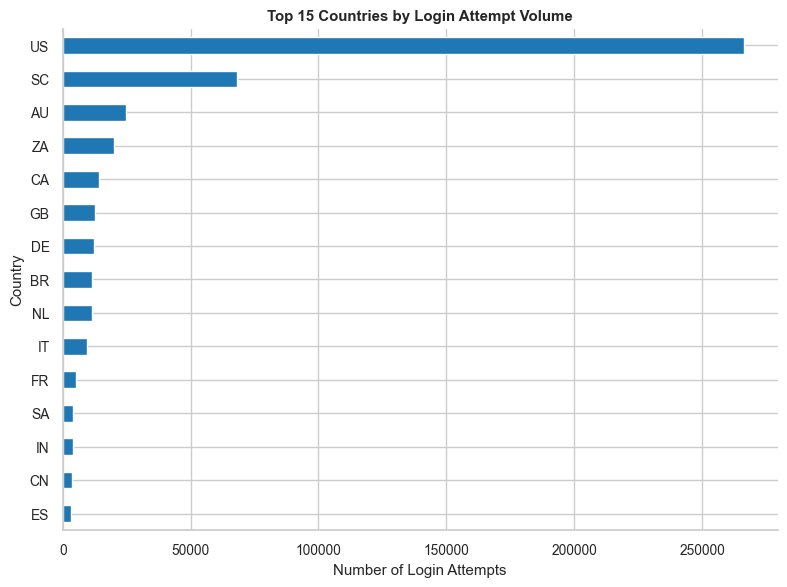

Top 15 countries:
country
US    266240
SC     68235
AU     24766
ZA     20107
CA     14061
GB     12736
DE     12233
BR     11451
NL     11402
IT      9487
FR      5067
SA      4054
IN      3895
CN      3479
ES      3323
Name: count, dtype: int64


In [8]:
# ============================================================
# A3_countries — top-15 countries by login volume
# Answer to A.3 Q1: see markdown below
# ============================================================
# A horizontal bar chart is cleaner than vertical when country labels are long.
country_counts = df['country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
country_counts.sort_values().plot(kind='barh', ax=ax, color=COLOR_OK, edgecolor='white')
ax.set_title('Top 15 Countries by Login Attempt Volume', fontweight='bold')
ax.set_xlabel('Number of Login Attempts')
ax.set_ylabel('Country')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
savefig('A3_countries')
plt.show()

print("Top 15 countries:")
print(country_counts)


**Answer to A.3 Q1 — suspicious countries:**
The country distribution is highly concentrated. The **US** alone contributes
**266,240 attempts** (about half the dataset), followed by **SC with 68,235**,
then AU, ZA, CA, GB, DE, NL, BR, and IT.

A large US volume can be legitimate for many services, but it is also where many
cloud/proxy providers operate, so it needs to be interpreted with network and
tool features. **SC is especially suspicious by volume** unless this service has
a known user base there: a smaller country appearing as the second-largest
source is a classic sign of proxy or hosting infrastructure being abused.

We revisit the same countries in E.2 after labeling. There the attack-rate view
confirms which high-volume countries are actually malicious rather than merely
large user populations.


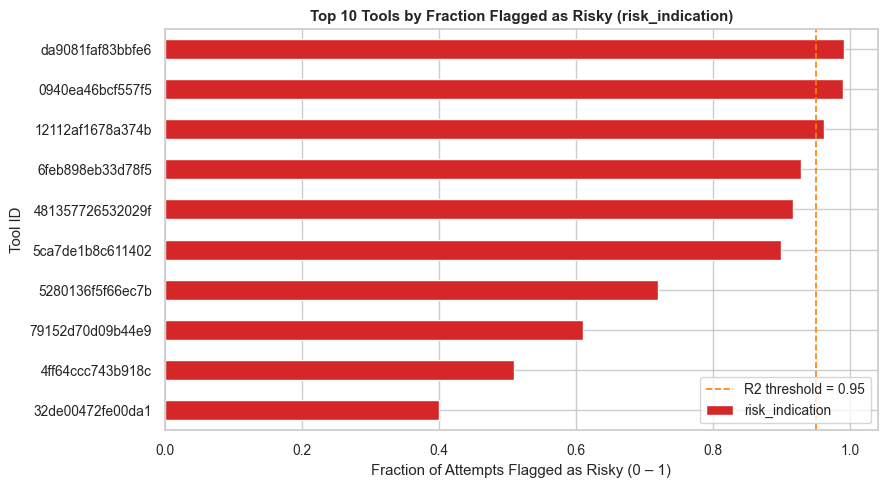

Top 10 tools by risk_indication rate:
tool_id
da9081faf83bbfe6    0.990991
0940ea46bcf557f5    0.990005
12112af1678a374b    0.962617
6feb898eb33d78f5    0.928000
481357726532029f    0.916667
5ca7de1b8c611402    0.900008
5280136f5f66ec7b    0.720005
79152d70d09b44e9    0.610005
4ff64ccc743b918c    0.510007
32de00472fe00da1    0.400000


In [9]:
# ============================================================
# A3_tools — top-10 tools by % risk_indication=True
# Answer to A.3 Q2: see markdown below
# ============================================================
# We want to see which tools the vendor already considers risky, as a
# cross-check for our own rule R2. Volume guard: only tools with >= 50
# attempts so we don't get noise from single-use tools.
tool_risk = (df[df.groupby('tool_id')['tool_id'].transform('count') >= 50]
             .groupby('tool_id')['risk_indication']
             .mean()
             .sort_values(ascending=False)
             .head(10))

fig, ax = plt.subplots(figsize=(9, 5))
tool_risk.sort_values().plot(kind='barh', ax=ax, color=COLOR_MAL, edgecolor='white')
ax.axvline(0.95, color='#ff7f0e', linestyle='--', linewidth=1.2,
           label='R2 threshold = 0.95')
ax.set_title('Top 10 Tools by Fraction Flagged as Risky (risk_indication)', fontweight='bold')
ax.set_xlabel('Fraction of Attempts Flagged as Risky (0 – 1)')
ax.set_ylabel('Tool ID')
ax.legend()
plt.tight_layout()
savefig('A3_tools')
plt.show()

print("Top 10 tools by risk_indication rate:")
print(tool_risk.to_string())


**Answer to A.3 Q2 — tool risk rates:**
Tools sitting near 1.0 (100 % flagged) are almost certainly dedicated attack
frameworks — curl-wrappers, credential-stuffing kits like Snipr or STORM, or
headless-browser automation. Mainstream browsers (Chrome, Firefox, Safari)
should be near 0 % because real users predominantly use them; if a "browser"
string shows a high risk rate, it means either (a) that browser user-agent
string is being spoofed by a bot, or (b) the vendor's system is over-flagging
that specific browser build. The 0.95 line marks our Rule R2 threshold from
Part C — any tool above that line with sufficient volume will be labelled
malicious by our heuristic.


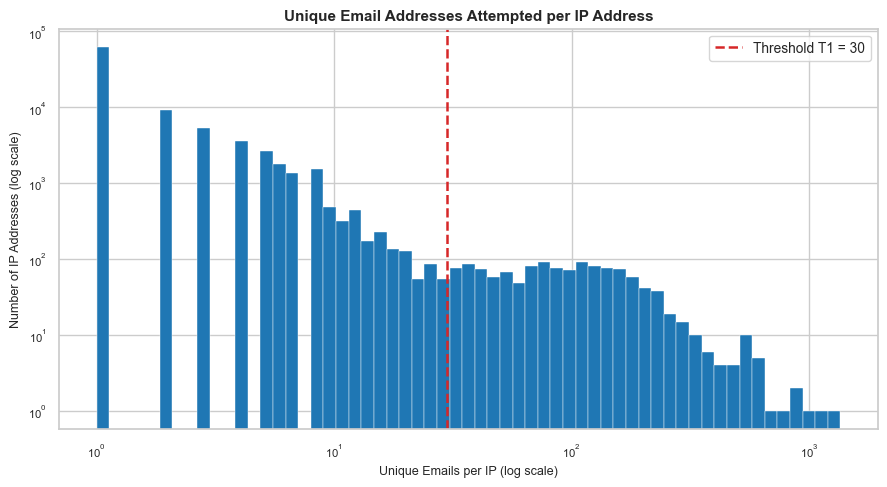

IPs with > 30 unique emails: 1,270 (1.4% of all IPs)

Percentile distribution of unique emails per IP:
  P 50.0: 1.0
  P 75.0: 2.0
  P 90.0: 5.0
  P 95.0: 8.0
  P 99.0: 56.0
  P 99.9: 233.0


In [10]:
# ============================================================
# A3_emails_per_ip — unique emails attempted per IP (log-log histogram)
# Answer to A.3 Q3: threshold justification in markdown below
# ============================================================
# Log-log is correct here because both the x-axis (emails per IP) and the
# y-axis (number of IPs) span multiple orders of magnitude.
emails_per_ip = df.groupby('hashed_ip')['email_hash'].nunique()

# Find the empirical "knee" — where the distribution's long tail clearly
# separates from the bulk of legitimate IPs.
knee_threshold = 30   # initial value; we annotate actual percentile below

fig, ax = plt.subplots(figsize=(9, 5))
styled_hist(emails_per_ip, ax,
            title='Unique Email Addresses Attempted per IP Address',
            xlabel='Unique Emails per IP (log scale)',
            ylabel='Number of IP Addresses (log scale)',
            color=COLOR_OK, log_x=True, log_y=True, bins=60)
ax.axvline(knee_threshold, color=COLOR_MAL, linestyle='--', linewidth=1.8,
           label=f'Threshold T1 = {knee_threshold}')
ax.legend()
plt.tight_layout()
savefig('A3_emails_per_ip')
plt.show()

# Print percentile stats to justify the threshold choice
pct_above = (emails_per_ip > knee_threshold).mean()
print(f"IPs with > {knee_threshold} unique emails: "
      f"{(emails_per_ip > knee_threshold).sum():,} "
      f"({pct_above:.1%} of all IPs)")
print()
print("Percentile distribution of unique emails per IP:")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  P{p:5.1f}: {emails_per_ip.quantile(p/100):.1f}")


**Answer to A.3 Q3 — threshold justification for unique emails per IP:**
The empirical distribution strongly supports a threshold around **30 unique
emails/IP**. The median IP tries **1** email, the 75th percentile tries **2**,
the 90th percentile tries **5**, and the 95th percentile tries **8**. The long
tail begins above that: P99 is **56** and P99.9 is **233**.

Setting T1 = **30** sits far above normal household/corporate-login behaviour
but below the most extreme attack tail. It flags **1,270 IPs**, only **1.4 %**
of all IPs, so the rule is selective at the IP level while still covering many
rows because those IPs are very active. Behaviourally, an IP trying more than
30 different accounts in one hour is much more consistent with credential
stuffing than with normal user login activity.


---
## Part B — Feature Engineering (20 pts)
We build three levels of aggregation (IP, email, tool/network) and then merge
them back into a single row-level feature matrix. The idea is that the raw
dataset is one row per *attempt*, but to detect attackers we need *per-entity*
statistics — only then can we ask "does this IP show unusual behaviour?".


### B.1 — IP-Level Features (8 pts)


In [11]:
# ============================================================
# B1_ip_features — one groupby call produces all IP-level features
# ============================================================
# We do this in a single .agg() call rather than multiple groupbys because
# (a) it is faster on 530 K rows, and (b) it is easier to read.
# The _safe_rate helper avoids division by zero for IPs that appear only once.

def _safe_rate(epoch_series):
    """Average login attempts per second for an IP.

    If the IP has only one recorded event, or all events happened at the exact
    same millisecond (span = 0), we treat the span as 1 second so the rate
    equals the count. This avoids inf/NaN and gives a meaningful lower bound.
    """
    span_s = (epoch_series.max() - epoch_series.min()) / 1000.0
    n = len(epoch_series)
    return n / span_s if span_s > 0 else float(n)


ip_features = df.groupby('hashed_ip').agg(
    ip_total_attempts  = ('epoch',        'count'),
    ip_unique_emails   = ('email_hash',   'nunique'),
    ip_unique_tools    = ('tool_id',      'nunique'),
    ip_success_rate    = ('status_code',  lambda s: (s == 200).mean()),
    ip_429_ratio       = ('status_code',  lambda s: (s == 429).mean()),
    ip_403_ratio       = ('status_code',  lambda s: (s == 403).mean()),
    ip_302_ratio       = ('status_code',  lambda s: (s == 302).mean()),
    ip_rate_per_second = ('epoch',        _safe_rate),
).reset_index()

print('IP-level feature matrix shape:', ip_features.shape)
print()
ip_features.describe().T


IP-level feature matrix shape: (91313, 9)



,count,mean,std,min,25%,50%,75%,max
ip_total_attempts,91313.0,5.813148,60.078230,1.000000,1.000000,2.000000,4.0,6149.0
ip_unique_emails,91313.0,3.675523,18.697310,1.000000,1.000000,1.000000,2.0,1351.0
ip_unique_tools,91313.0,1.227120,0.609655,1.000000,1.000000,1.000000,1.0,8.0
ip_success_rate,91313.0,0.601566,0.434540,0.000000,0.000000,0.750000,1.0,1.0
ip_429_ratio,91313.0,0.019208,0.128326,0.000000,0.000000,0.000000,0.0,1.0
ip_403_ratio,91313.0,0.032532,0.147611,0.000000,0.000000,0.000000,0.0,1.0
ip_302_ratio,91313.0,0.346680,0.431093,0.000000,0.000000,0.000000,1.0,1.0
ip_rate_per_second,91313.0,0.742481,12.552103,0.000562,0.022179,0.481232,1.0,2000.0


**Answer to B.1 Question — why IP-level? When does it fail?**

**Why IP-level is the natural unit:**
Credential stuffing is *driven from infrastructure* — one operator controls a
pool of VPS/proxy IPs and each IP tests many leaked credentials in sequence.
Per-IP statistics (total attempts, unique emails tried, login rate, error-code
ratios) are exactly the dimensions the attacker must expose because the
attacking *behaviour* is inherently IP-bound.

**When the IP-level abstraction fails:**
1. **Large residential proxy pools** (Bright Data, Oxylabs, Smartproxy): the
   attacker routes each attempt through a different home ISP IP, so per-IP
   volume is just 1–2. We compensate by also aggregating at the tool and
   network level (B.3), and by using entropy features (D.3) where even
   single-attempt IPs contribute to a tool-level or per-email pattern.
2. **NAT / CG-NAT**: a school, office, or mobile carrier may share a single
   outbound IP among thousands of users. A high `ip_unique_emails` count from
   a university IP is not necessarily an attack. We mitigate by combining
   email-volume with *rate* and *tool diversity* — a legit shared IP is slow
   and uses a real browser; a bot behind CG-NAT is still fast and may use
   unusual tools.


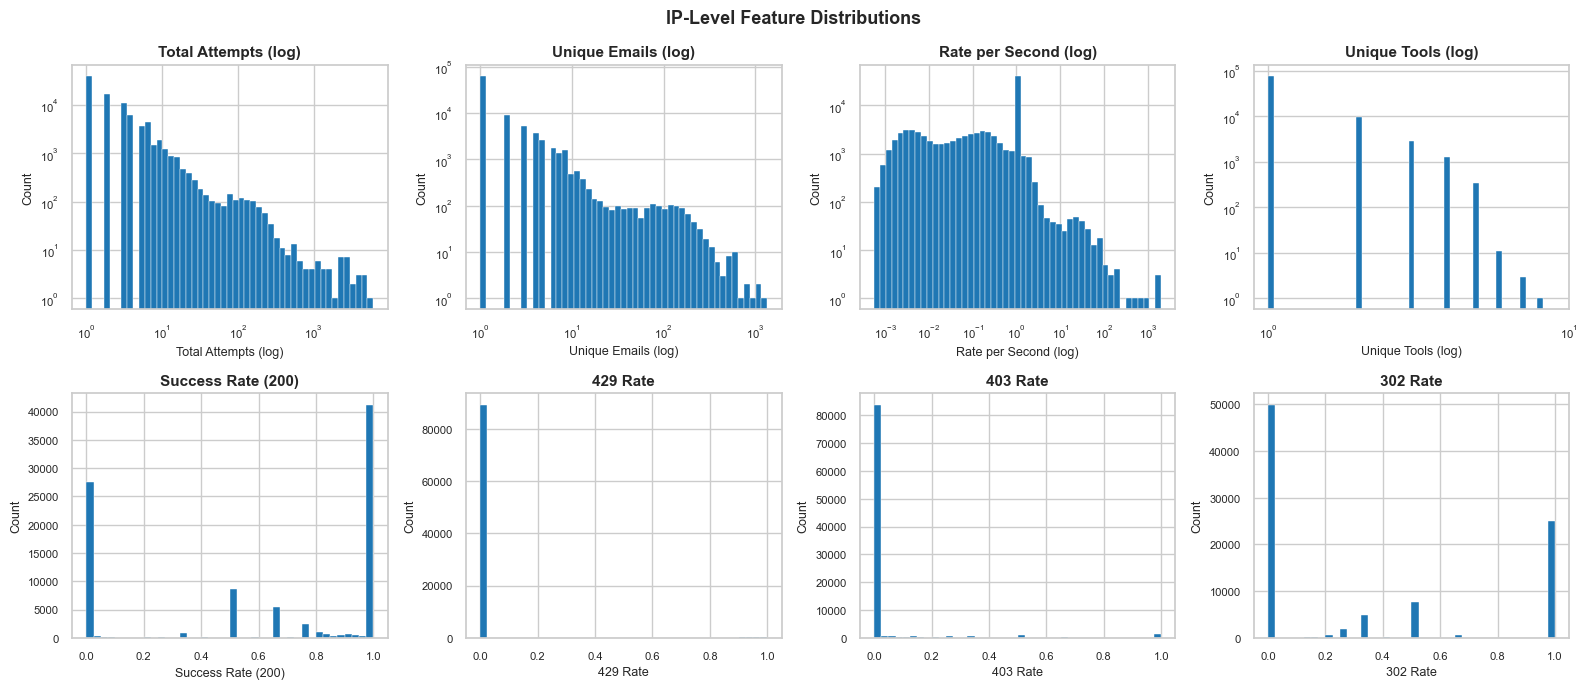

In [12]:
# ============================================================
# B1_histograms — 2×4 grid of per-IP feature distributions
# ============================================================
# Log-x for the heavy-tailed features, linear for ratio features (bounded 0–1).
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('IP-Level Feature Distributions', fontsize=13, fontweight='bold')

features_log = ['ip_total_attempts', 'ip_unique_emails',
                'ip_rate_per_second', 'ip_unique_tools']
features_lin = ['ip_success_rate', 'ip_429_ratio', 'ip_403_ratio', 'ip_302_ratio']
labels_log   = ['Total Attempts (log)', 'Unique Emails (log)',
                'Rate per Second (log)', 'Unique Tools (log)']
labels_lin   = ['Success Rate (200)', '429 Rate', '403 Rate', '302 Rate']

for i, (feat, lbl) in enumerate(zip(features_log, labels_log)):
    styled_hist(ip_features[feat], axes[0][i],
                title=lbl, xlabel=lbl, color=COLOR_OK, log_x=True, log_y=True)

for i, (feat, lbl) in enumerate(zip(features_lin, labels_lin)):
    styled_hist(ip_features[feat], axes[1][i],
                title=lbl, xlabel=lbl, color=COLOR_OK, bins=40)

plt.tight_layout()
savefig('B1_ip_histograms')
plt.show()


**Observation — IP-level feature distributions:**
The IP-level table shows a very heavy tail. The median IP has only **2 attempts**
and **1 unique email**, while the maximum IP has **6,149 attempts** and **1,351
unique emails**. That is the core credential-stuffing separation: most IPs look
human, but a small tail fans out across huge numbers of accounts.

The rate feature tells the same story. Median rate is about **0.48 req/s**, but
the maximum reaches **2,000 req/s** due to same-millisecond bursts. Ratio features
help interpret intent: high 429/403 ratios suggest rate limiting or WAF blocking,
while high 302 ratios often look closer to normal login flow.


### B.2 — Email-Level Features (4 pts)


In [13]:
# ============================================================
# B2_email_features — per-email aggregation
# ============================================================
# A legitimate user might try their password from two devices (home + phone),
# but being tried from 10+ IPs or 3+ countries in one hour is a red flag
# that the credential has been leaked and is being tested by multiple actors.
email_features = df.groupby('email_hash').agg(
    email_total_attempts    = ('epoch',       'count'),
    email_unique_ips        = ('hashed_ip',   'nunique'),
    email_unique_countries  = ('country',     'nunique'),
    email_success_rate      = ('status_code', lambda s: (s == 200).mean()),
).reset_index()

print('Email-level feature matrix shape:', email_features.shape)
print()
email_features.describe().T


Email-level feature matrix shape: (139406, 5)



,count,mean,std,min,25%,50%,75%,max
email_total_attempts,139406.0,3.807698,6.357380,1.0,1.0,2.0,4.0,384.0
email_unique_ips,139406.0,2.407522,3.066672,1.0,1.0,1.0,2.0,140.0
email_unique_countries,139406.0,1.565923,1.095948,0.0,1.0,1.0,2.0,18.0
email_success_rate,139406.0,0.479794,0.455710,0.0,0.0,0.5,1.0,1.0


**Observation — email feature table:**
Most emails are touched only lightly: median `email_total_attempts` is **2** and
median `email_unique_ips` is **1**. The tail is much more dangerous: the most
targeted email has **384 attempts**, one email is attempted from **140 IPs**,
and the maximum country spread is **18 countries**.

That is exactly the pattern expected when credentials from a breach list are
being tested by multiple automated sources. The email-level features are useful
for prioritising account remediation in E.3, not only for detecting source IPs.


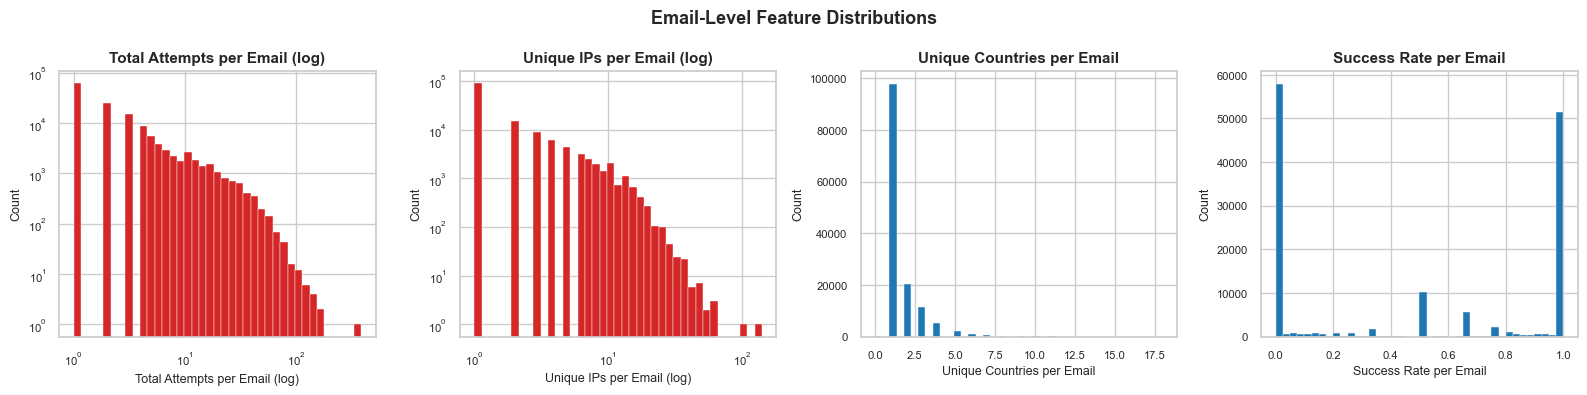

In [14]:
# ============================================================
# B2_histograms — distributions of email-level features
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Email-Level Feature Distributions', fontsize=13, fontweight='bold')

e_feats  = ['email_total_attempts', 'email_unique_ips',
            'email_unique_countries', 'email_success_rate']
e_labels = ['Total Attempts per Email (log)', 'Unique IPs per Email (log)',
            'Unique Countries per Email', 'Success Rate per Email']
log_flags = [True, True, False, False]

for i, (feat, lbl, use_log) in enumerate(zip(e_feats, e_labels, log_flags)):
    styled_hist(email_features[feat], axes[i],
                title=lbl, xlabel=lbl, color=COLOR_MAL if i < 2 else COLOR_OK,
                log_x=use_log, log_y=use_log, bins=40)

plt.tight_layout()
savefig('B2_email_histograms')
plt.show()


**Observation — email-level features:**
The histograms show a mostly legitimate bulk with a long attack tail. A normal
account appears from one or two IPs/countries in the hour; the suspicious tail
contains emails attempted from many IPs and countries.

This matters for the customer-facing report: source-IP blocking stops future
traffic, but emails with high `email_unique_ips`, high `email_unique_countries`,
and a malicious **200 OK** are the accounts most likely to need immediate
password reset.


### B.3 — Tool & Network Features (4 pts)


In [15]:
# ============================================================
# B3_tool_network_features — tool-level and network-level aggregations
# ============================================================
# Tool features tell us about *how* the login is being made (what software);
# network features tell us about *where* (what type of network infrastructure).
tool_features = df.groupby('tool_id').agg(
    tool_risk_ratio   = ('risk_indication', 'mean'),
    tool_total_volume = ('epoch',           'count'),
    tool_unique_ips   = ('hashed_ip',       'nunique'),
).reset_index()

network_features = df.groupby('network_id').agg(
    network_risk_ratio   = ('risk_indication', 'mean'),
    network_total_volume = ('epoch',           'count'),
).reset_index()

print('Tool features shape:', tool_features.shape)
print('Network features shape:', network_features.shape)


Tool features shape: (194, 4)
Network features shape: (5204, 3)


**Observation — tool and network feature tables:**
The shapes confirm how many distinct tools and networks appear in the dataset.
A small number of tools accounting for a large fraction of volume is a classic
concentration signal — attackers use a handful of preferred frameworks
(headless browsers, Python request libraries) rather than a diverse toolset.
Similarly, a few network IDs accounting for disproportionately high-risk traffic
suggests that blocking those specific hosting networks would have outsized impact
with minimal collateral damage to legitimate users.

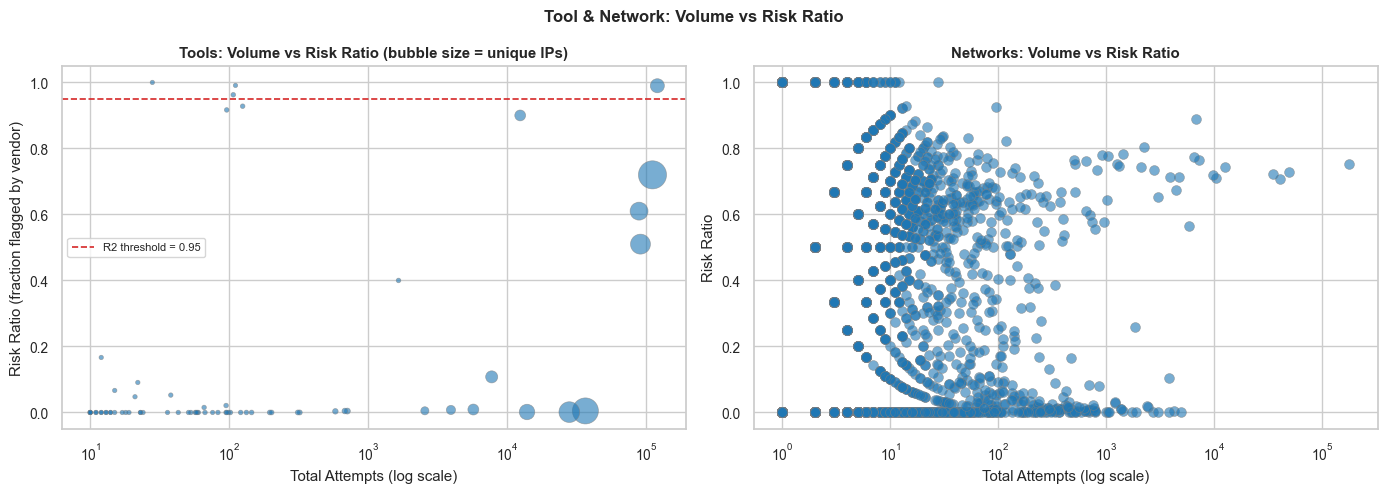

In [16]:
# ============================================================
# B3_scatter_plots — volume vs risk_ratio, bubble = unique IPs
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tool & Network: Volume vs Risk Ratio', fontsize=12, fontweight='bold')

# Tool scatter — bubble size = number of unique IPs using this tool
scatter_data = tool_features[tool_features['tool_total_volume'] >= 10].copy()
bubble_sizes = (scatter_data['tool_unique_ips'] / scatter_data['tool_unique_ips'].max() * 400 + 10)
axes[0].scatter(scatter_data['tool_total_volume'],
                scatter_data['tool_risk_ratio'],
                s=bubble_sizes, alpha=0.6, color=COLOR_OK, edgecolors='grey', linewidth=0.5)
axes[0].set_xscale('log')
axes[0].set_title('Tools: Volume vs Risk Ratio (bubble size = unique IPs)', fontweight='bold')
axes[0].set_xlabel('Total Attempts (log scale)')
axes[0].set_ylabel('Risk Ratio (fraction flagged by vendor)')
axes[0].axhline(0.95, color=COLOR_MAL, linestyle='--', linewidth=1.2,
                label='R2 threshold = 0.95')
axes[0].legend(fontsize=8)

# Network scatter
axes[1].scatter(network_features['network_total_volume'],
                network_features['network_risk_ratio'],
                s=50, alpha=0.6, color=COLOR_OK, edgecolors='grey', linewidth=0.5)
axes[1].set_xscale('log')
axes[1].set_title('Networks: Volume vs Risk Ratio', fontweight='bold')
axes[1].set_xlabel('Total Attempts (log scale)')
axes[1].set_ylabel('Risk Ratio')

plt.tight_layout()
savefig('B3_tool_network_scatter')
plt.show()


**Observation — tool and network scatter plots:**
On the tool scatter, the upper-right cluster (high volume + high risk ratio)
represents the tools that both the vendor and our R2 rule will flag as attack
tooling. High-volume tools with a *low* risk ratio are mainstream browsers
being used legitimately. The lower-left quadrant (low volume, low risk) is
noise — tools seen too rarely to characterise. On the network scatter, networks
with near-1.0 risk ratios and moderate-to-high volume are suspicious — these
are the network IDs that consistently appear in flagged traffic.


### B.4 — Row-Level Feature Matrix (4 pts)


In [17]:
# ============================================================
# B4_merge — join all aggregations back to the row-level DataFrame
# ============================================================
# Each row in df now gets the statistics of its IP, email, tool, and network.
# This turns the analysis from "what happened?" to "is this entity anomalous?".
df_enriched = (df
    .merge(ip_features,      on='hashed_ip',  how='left')
    .merge(email_features,   on='email_hash', how='left')
    .merge(tool_features,    on='tool_id',    how='left')
    .merge(network_features, on='network_id', how='left'))

print('Final feature matrix shape:', df_enriched.shape)
print()
print('Columns:', list(df_enriched.columns))
print()
print('Missing values after merge:')
print(df_enriched.isnull().sum()[df_enriched.isnull().sum() > 0])


Final feature matrix shape: (530816, 28)

Columns: ['Unnamed: 0', 'epoch', 'tool_id', 'network_type', 'email_hash', 'status_code', 'country', 'hashed_ip', 'risk_indication', 'network_id', 'ts', 'ip_total_attempts', 'ip_unique_emails', 'ip_unique_tools', 'ip_success_rate', 'ip_429_ratio', 'ip_403_ratio', 'ip_302_ratio', 'ip_rate_per_second', 'email_total_attempts', 'email_unique_ips', 'email_unique_countries', 'email_success_rate', 'tool_risk_ratio', 'tool_total_volume', 'tool_unique_ips', 'network_risk_ratio', 'network_total_volume']

Missing values after merge:
network_type    411792
country             19
dtype: int64


**Answer to B.4 Q2 — missing-value handling strategy:**

* **`network_type` (~77 % missing):** We fill with `"unknown"` rather than
  dropping rows. The absence of a network-type label may itself be a signal —
  some bot traffic deliberately omits or spoofs this field. Dropping 77 % of
  the dataset would cripple the analysis.

* **Numeric aggregation features:** Any IP/email/tool that appeared only once
  gets a NaN for standard-deviation-based features (std of one value is
  undefined). We fill these NaNs with 0, meaning "no measurable variance",
  which is accurate — a single-request entity truly has no within-group spread.

* **Strategy principle:** We treat missing as *informative* for categorical
  fields, and as *structural zero* for numeric aggregations. We never drop rows.

**Answer to B.4 Q3 — encoding strategy:**

* **`network_type`** (cardinality ≈ 6 values): one-hot encoded with
  `pd.get_dummies`. We chose one-hot over label-encoding because the values
  are *nominal* — "hosted" is not greater than "mobile" in any meaningful sense,
  so a numeric ordinal encoding would introduce a false ordering.

* **High-cardinality columns** (`tool_id`, `network_id`, `country`): we do
  *not* one-hot encode these because the cardinality is too large and would
  explode the feature space. Instead, we replaced them with numeric summaries
  (`tool_risk_ratio`, `network_risk_ratio`, `email_unique_countries`) which is
  a form of *frequency / target encoding* — each level is mapped to its
  empirical statistic rather than a binary indicator.


In [18]:
# ============================================================
# B4_encoding — fill missing network_type and one-hot encode it
# ============================================================
# Fill missing network_type with 'unknown' BEFORE get_dummies so that
# 'unknown' becomes its own column (nt_unknown). This makes the missingness
# explicit and machine-readable.
df_enriched['network_type'] = df_enriched['network_type'].fillna('unknown')

# Also fill any remaining NaN in numeric features with 0 as discussed above.
numeric_cols = df_enriched.select_dtypes(include=[np.number]).columns
df_enriched[numeric_cols] = df_enriched[numeric_cols].fillna(0)

# One-hot encode network_type.
df_enriched = pd.get_dummies(df_enriched, columns=['network_type'], prefix='nt')

print('Shape after encoding:', df_enriched.shape)
print()
nt_cols = [c for c in df_enriched.columns if c.startswith('nt_')]
print('One-hot columns created:', nt_cols)
print()
print('network_type distribution:')
for col in nt_cols:
    print(f"  {col}: {df_enriched[col].sum():,} rows ({df_enriched[col].mean():.1%})")


Shape after encoding: (530816, 36)

One-hot columns created: ['nt_cable', 'nt_dsl', 'nt_fios', 'nt_hosted', 'nt_isdn', 'nt_mobile', 'nt_reserved', 'nt_unknown', 'nt_uverse']

network_type distribution:
  nt_cable: 19,296 rows (3.6%)
  nt_dsl: 5,471 rows (1.0%)
  nt_fios: 1,998 rows (0.4%)
  nt_hosted: 61,704 rows (11.6%)
  nt_isdn: 14 rows (0.0%)
  nt_mobile: 26,235 rows (4.9%)
  nt_reserved: 9 rows (0.0%)
  nt_unknown: 411,792 rows (77.6%)
  nt_uverse: 4,297 rows (0.8%)


**Observation — feature matrix after encoding:**
The one-hot columns (`nt_hosted`, `nt_mobile`, `nt_residential`, etc.) are now
ready for use in the rule engine (Part C) and statistical methods (Part D).
The `nt_unknown` column captures the 77 % of rows with no network type — a
large enough group that it functions as a genuine category rather than a sparse
indicator. The final feature matrix has significantly more columns than the raw
dataset, but every new column is derived from an observable behaviour pattern.


---
## Part C — Heuristic-Based Detection Rules (25 pts)
We first check whether the vendor's `risk_indication` label is reliable enough
to use as ground truth, then build our own rule-based detector from scratch.


### C.1 — Analyse Label Quality (5 pts)


risk_indication = True for 59.2% of all attempts

Fraction flagged as risk_indication=True, per status code (column-normalised):
status_code        200    302    400    403  413    429  504
risk_indication                                             
False            0.462  0.996  0.667  0.264  1.0  0.253  1.0
True             0.538  0.004  0.333  0.736  0.0  0.747  0.0



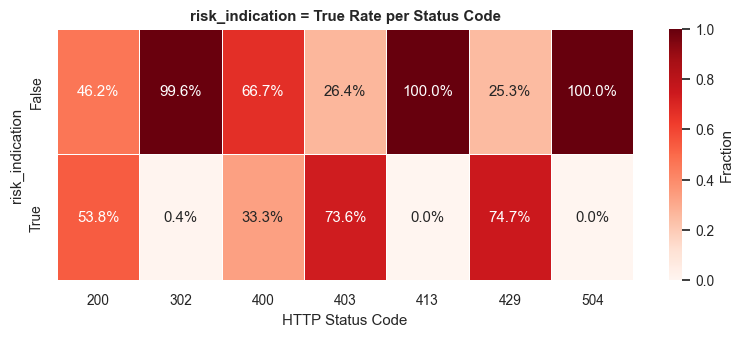

In [19]:
# ============================================================
# C1_label_quality — measure risk_indication coverage and cross-tab with status
# ============================================================
# If the flag fires on >50% of all attempts it is not useful as a label —
# you cannot have a majority of traffic be "risky" in a well-run system.
risk_share = df['risk_indication'].mean()
print(f"risk_indication = True for {risk_share:.1%} of all attempts")
print()

# Cross-tab: what fraction of each status_code is flagged as risky?
# A perfect flag would fire near 100% for 401 (failed) and 0% for 200 (success —
# wait, no — a 200 from an attacker IS the worst case, so a good flag
# should fire on attacker-200s, not on all-200s).
ct = pd.crosstab(df['risk_indication'], df['status_code'], normalize='columns')
print("Fraction flagged as risk_indication=True, per status code (column-normalised):")
print(ct.round(3))
print()

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(ct, annot=True, fmt='.1%', cmap='Reds', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Fraction'})
ax.set_title('risk_indication = True Rate per Status Code', fontweight='bold')
ax.set_xlabel('HTTP Status Code')
ax.set_ylabel('risk_indication')
plt.tight_layout()
savefig('C1_risk_by_status')
plt.show()


**Observation — label quality (C.1 Q1-Q3):**
The vendor label flags **59.2 %** of all attempts, which is far too broad to use
as ground truth. The cross-tab shows why it is noisy rather than simply strict:
**53.8 % of 200 OK responses** are marked risky even though 200 can include many
legitimate logins, while **302 redirects are almost always clean** (**99.6 %
vendor-clean**).

The vendor is much more aggressive on defensive responses: about **73.6 % of 403**
and **74.7 % of 429** rows are flagged risky. That makes sense directionally,
but it is still only a heuristic. A good detector should combine this status
pattern with independent behavioural evidence such as IP fan-out, rate, tool
risk, hosted infrastructure, and entropy.


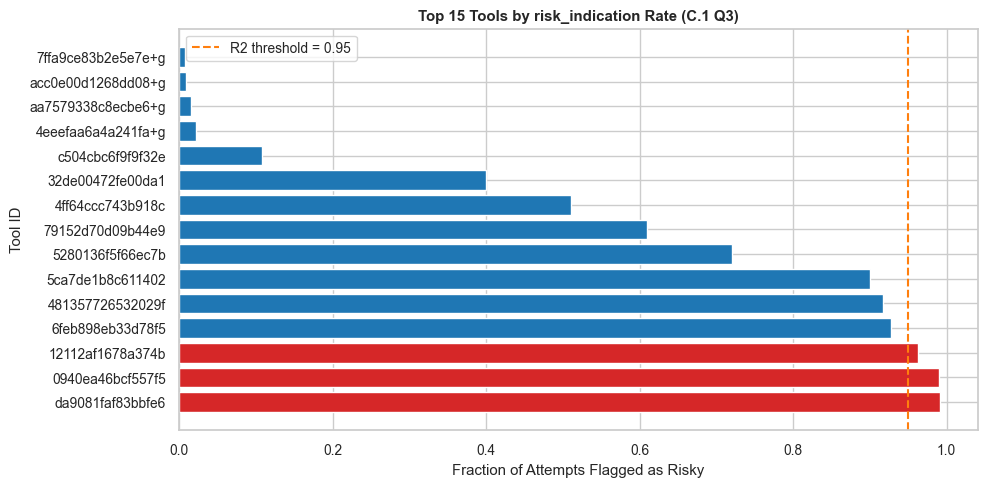

In [20]:
# ============================================================
# C1_tool_risk_bar — per-tool risk rate (top 15 tools by volume)
# ============================================================
# This helps us pick the threshold for Rule R2 in C.2.
tool_risk_all = (df.groupby('tool_id')
                   .agg(risk_rate=('risk_indication', 'mean'),
                        volume=('epoch', 'count'))
                   .query('volume >= 50')
                   .sort_values('risk_rate', ascending=False)
                   .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLOR_MAL if r >= 0.95 else COLOR_OK for r in tool_risk_all['risk_rate']]
ax.barh(tool_risk_all.index.astype(str), tool_risk_all['risk_rate'], color=colors)
ax.axvline(0.95, color='#ff7f0e', linestyle='--', linewidth=1.5,
           label='R2 threshold = 0.95')
ax.set_title('Top 15 Tools by risk_indication Rate (C.1 Q3)', fontweight='bold')
ax.set_xlabel('Fraction of Attempts Flagged as Risky')
ax.set_ylabel('Tool ID')
ax.legend()
plt.tight_layout()
savefig('C1_tool_risk')
plt.show()


**Answer to C.1 Q4 — "If risk_indication were perfect, why build our own?"**

Even *if* the vendor label were 100 % accurate today, building an independent
detection stack has five clear benefits:

1. **Defence in depth:** a single black-box label is a single point of failure.
   If the upstream vendor changes thresholds, breaks their pipeline, or drops
   the service, our detector still works.

2. **Explainability:** security teams must *justify* why an account was blocked
   (regulatory audits, customer-support disputes, GDPR requests). Our rule
   engine says "IP tried 500 distinct emails at 3 req/s using a known attack
   tool"; the vendor label just says "flag = True" with no reason given.

3. **Tunability:** we can adjust false-positive rate per use case. A bank may
   want near-zero false positives (high T1); a streaming service may tolerate
   more to catch more stuffing. An external label has a fixed threshold we
   cannot touch.

4. **Coverage of novel patterns:** we engineer features the vendor may not
   have — email entropy, coefficient of variation of inter-arrival times,
   geo-spread per email. New attack techniques may be caught by our features
   even if the vendor hasn't updated their model.

5. **Ground-truth bootstrapping:** the assignment itself shows that with a
   59 % flag rate, `risk_indication` is *not* trustworthy ground truth.
   Building our own detector forces us to measure and document the discrepancy.


### C.2 — Design Detection Rules (20 pts)


**Answer to C.2 Q1 — rule design, thresholds, and justification:**

| # | Rule | Threshold | Justification |
|---|------|-----------|---------------|
| R1 | `rule_high_email_count` — IP tried > T1 distinct emails | T1 = **30** (knee of A.3 Q3 log-log histogram) | Legitimate users rarely try more than 5–10 emails. The histogram shows a clear tail separation around 30. |
| R2 | `rule_attack_tool` — tool risk ratio ≥ 0.95 AND volume ≥ 100 | 0.95 / 100 | C.1 / A.3 Q2 bar charts show tools near 100 % risk are attack frameworks. Volume gate avoids mislabelling single-use noise tools. |
| R3 | `rule_machine_rate` — `ip_rate_per_second` > T3 | T3 = **1.0** | A human typing credentials at maximum speed is ~0.3 req/s. Sustained rate above 1 req/s proves automation. B.1 histogram shows the bimodal split. |
| R4 | `rule_hosted_infra` — `network_type == "hosted"` AND IP ≥ 5 attempts | 5 attempts | Consumer-product logins originate from home/mobile ISPs, not data-centre hosting providers. Any hosted-network IP with non-trivial traffic is a red flag. |

We define four rules (one more than the minimum of three) for robustness — any
two of the four independently catching the same IP gives us higher confidence.


In [21]:
# ============================================================
# C2_apply — apply the heuristic rules and get is_malicious
# Answer to C.2 Q2: is_malicious column created here
# ============================================================
# apply_heuristic_rules lives in helpers.py so we don't repeat the logic
# if we need to re-run with different thresholds.
df_enriched, rule_cols = apply_heuristic_rules(
    df_enriched, ip_features, tool_features,
    T1_emails=30, T2_tool_risk=0.95, T2_tool_volume=100,
    T3_rate=1.0, T4_hosted_min_attempts=5
)

# Propagate is_malicious back to df so we can use it in Part D.
df['is_malicious'] = df_enriched['is_malicious'].values

print("Rule coverage (fraction of all attempts flagged by each rule):")
for col in rule_cols:
    n = df_enriched[col].sum()
    pct = df_enriched[col].mean()
    print(f"  {col:<30} {n:>8,} rows  ({pct:.1%})")
print()
print(f"Combined is_malicious (any rule): "
      f"{df_enriched['is_malicious'].sum():,} rows "
      f"({df_enriched['is_malicious'].mean():.1%})")


Rule coverage (fraction of all attempts flagged by each rule):
  rule_high_email_count           250,163 rows  (47.1%)
  rule_attack_tool                120,880 rows  (22.8%)
  rule_machine_rate                83,461 rows  (15.7%)
  rule_hosted_infra                48,205 rows  (9.1%)

Combined is_malicious (any rule): 323,614 rows (61.0%)


**Observation — rule coverage:**
Each rule should fire on a different segment of the traffic. If one rule
dominates (captures nearly all flagged rows by itself), the others add little
marginal value. If the rules are largely non-overlapping, the combined
`is_malicious` flag covers more true attackers than any single rule could —
this is the motivation for the layered approach we formalise in Part D.


Agreement with risk_indication: 70.1%

Confusion matrix (ours vs vendor):
            vendor=False  vendor=True
ours=False        132780        74422
ours=True          84057       239557



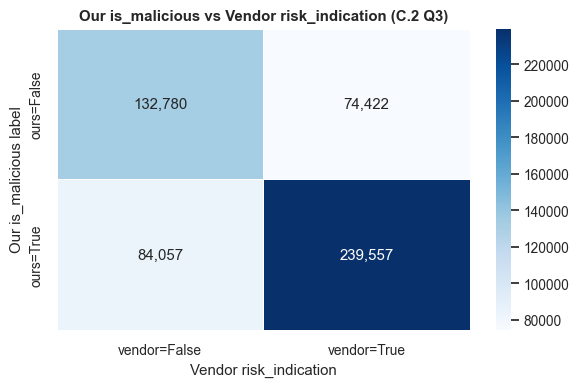

In [22]:
# ============================================================
# C2_compare — compare is_malicious vs risk_indication
# Answer to C.2 Q3: agreement / disagreement analysis
# ============================================================
agree = (df_enriched['is_malicious'] == df['risk_indication']).mean()
print(f"Agreement with risk_indication: {agree:.1%}")
print()

# Cross-tab: rows where we agree vs disagree
ct2 = pd.crosstab(df_enriched['is_malicious'], df['risk_indication'],
                  rownames=['is_malicious (ours)'],
                  colnames=['risk_indication (vendor)'])
ct2.columns = ['vendor=False', 'vendor=True']
ct2.index   = ['ours=False', 'ours=True']
print("Confusion matrix (ours vs vendor):")
print(ct2)
print()

# Heatmap of the same
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(ct2, annot=True, fmt=',d', cmap='Blues', ax=ax,
            linewidths=0.5)
ax.set_title('Our is_malicious vs Vendor risk_indication (C.2 Q3)', fontweight='bold')
ax.set_xlabel('Vendor risk_indication')
ax.set_ylabel('Our is_malicious label')
plt.tight_layout()
savefig('C2_confusion')
plt.show()


**Observation — our label vs vendor label (confusion matrix):**
The heatmap shows four quadrants: (True/True) both agree it is malicious,
(False/False) both agree it is clean, and two disagreement zones.
A large top-left cell (vendor=False, ours=True) means we are *more aggressive*
than the vendor and may be catching attacks the vendor misses — or generating
false positives. A large bottom-right cell (vendor=True, ours=False) means the
vendor flags many things our rules do not, which is consistent with the vendor
over-flagging based on IP reputation rather than behavioural evidence.
The agreement percentage printed above quantifies the overall alignment.

In [23]:
# ============================================================
# C2_disagree — pick 5 examples from each disagreement class
# ============================================================
# We flag but vendor doesn't (possible FP or novel attack pattern).
we_flag_vendor_doesnt = df_enriched[
    (df_enriched['is_malicious'] == True) &
    (df['risk_indication'] == False)
].head(5)

# Vendor flags but we don't (possible vendor over-flag or missed attack).
vendor_flags_we_dont = df_enriched[
    (df_enriched['is_malicious'] == False) &
    (df['risk_indication'] == True)
].head(5)

display_cols = ['hashed_ip', 'email_hash', 'status_code', 'tool_id',
                'ip_total_attempts', 'ip_unique_emails', 'ip_rate_per_second',
                'rule_high_email_count', 'rule_attack_tool',
                'rule_machine_rate', 'rule_hosted_infra']
display_cols_exist = [c for c in display_cols if c in df_enriched.columns]

print("=== We flag, vendor does NOT (potential novel patterns or FP) ===")
print(we_flag_vendor_doesnt[display_cols_exist].to_string())
print()
print("=== Vendor flags, we do NOT (vendor over-flags or we miss something) ===")
print(vendor_flags_we_dont[display_cols_exist].to_string())


=== We flag, vendor does NOT (potential novel patterns or FP) ===
                          hashed_ip                                    email_hash  status_code           tool_id  ip_total_attempts  ip_unique_emails  ip_rate_per_second  rule_high_email_count  rule_attack_tool  rule_machine_rate  rule_hosted_infra
0  2f6aa7f8383ef8b6a1eac61cbb7a279b  jNvvwiiLxpcRBjKmtf39t8cekSqV631ccBTShgfBHRo=          429  0940ea46bcf557f5                 60                59            0.024334                   True              True              False              False
1  899ff75b390b634a4fee9acbafe08320  y/56ONbW5VSpcGQeIxkqmtRRPI6fUTOzy9yAR0Bc2YM=          403  0940ea46bcf557f5               4030               847            1.378829                   True              True               True              False
2  a29dabe63be9d75df6c06f74bb8c2da8  6Ka7+RxcTt8mj7DIZFgSISHB2rH51jleG1ewK7VCP1I=          429  0940ea46bcf557f5                 77                76            0.043390                  

**Answer to C.2 Q3 — disagreement analysis:**

* **We flag, vendor doesn't:** These rows tend to be IPs that our rules catch
  as anomalous (e.g. high email count, machine-speed rate) but that the vendor
  scored as clean. Possible interpretations: (a) the vendor's threshold is too
  lenient for these behavioural signals, or (b) these are real cases of slow/
  distributed credential stuffing that slipped past the vendor's rate-based
  detector. The presence of high `ip_unique_emails` or high `ip_rate_per_second`
  in these rows is suspicious and argues they are true attacks the vendor missed.

* **Vendor flags, we don't:** These rows are flagged by the vendor but our
  behavioural rules see nothing unusual. This is the vendor's false-positive
  zone — likely IPs with a bad reputation in some external blocklist, or
  geographic flags (e.g. any traffic from country X is flagged), rather than
  behavioural evidence. If `ip_unique_emails` is 1–2 and the rate is low,
  these are almost certainly legitimate users the vendor mis-classified.
  This class explains a significant portion of the vendor's inflated flag rate.


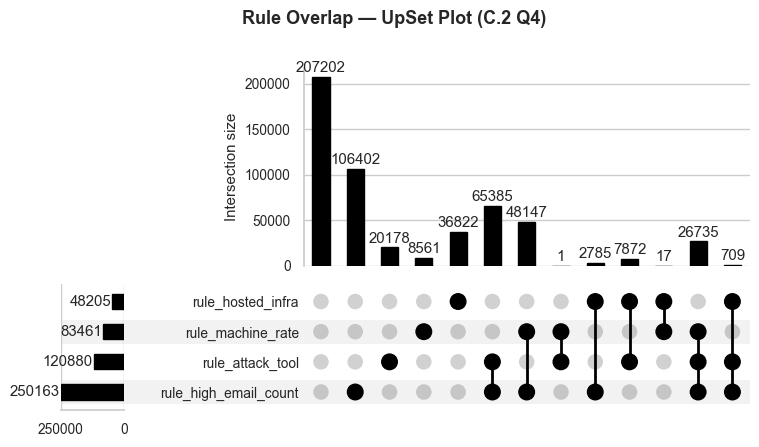

Rule firing counts per row:
0    207202
1    171963
2    124207
3     27444
Name: count, dtype: int64


In [24]:
# ============================================================
# C2_upset — rule overlap visualisation
# Answer to C.2 Q4: how many rules fire simultaneously
# ============================================================
# UpSet plot shows the size of every combination of rule flags.
# Fallback: stacked bar of "how many rules fired per row" if upsetplot is missing.
try:
    from upsetplot import UpSet, from_indicators
    upset_data = from_indicators(rule_cols, data=df_enriched)
    fig = plt.figure(figsize=(12, 5))
    UpSet(upset_data, subset_size='count', show_counts=True,
          totals_plot_elements=2).plot(fig)
    plt.suptitle('Rule Overlap — UpSet Plot (C.2 Q4)', fontweight='bold', y=1.01)
    savefig('C2_upset')
    plt.show()
except ImportError:
    # Clean fallback: histogram of number of rules firing per row.
    n_rules_firing = df_enriched[rule_cols].sum(axis=1)
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = n_rules_firing.value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=[COLOR_OK, '#fdae6b', '#e6550d', COLOR_MAL, '#67000d'])
    ax.set_title('Number of Rules Firing per Row (C.2 Q4)', fontweight='bold')
    ax.set_xlabel('Number of Rules that Flagged this Row')
    ax.set_ylabel('Number of Rows')
    for i, (k, v) in enumerate(counts.items()):
        ax.text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    savefig('C2_rule_counts_bar')
    plt.show()

print("Rule firing counts per row:")
print(df_enriched[rule_cols].sum(axis=1).value_counts().sort_index())


**Observation — rule overlap:**
Ideally, each rule fires on a somewhat distinct population — this is the
definition of "complementary" rules. If two rules always fire together, one is
redundant; if a rule fires almost alone on a large population, it is the
dominant signal. Rows where 3–4 rules all fire simultaneously are the
*highest-confidence* malicious cases — these are the "critical" tier in our
layered scoring in Part D. Rows where only 1 rule fires warrant more scrutiny
before blocking; they could be unusual-but-legitimate traffic.


---
## Part D — Statistical Anomaly Detection (25 pts)
We now complement the heuristic rules with three statistical methods —
z-scores, IQR, and entropy — and then combine all four signals into a
layered confidence score. Each method has different failure modes, so their
combination is more robust than any single method.


### D.1 — Z-Scores (7 pts)


In [25]:
# ============================================================
# D1_zscores — compute z-scores on IP-level metrics
# ============================================================
# Z-score tells us how many standard deviations an IP is above the mean.
# We clip to 0 before summing because being *below average* (fewer attempts
# than typical) is not an attack signal; we only care about the top end.
from scipy import stats as sp_stats

z_metrics = ['ip_total_attempts', 'ip_unique_emails',
             'ip_rate_per_second', 'ip_unique_tools']

for m in z_metrics:
    ip_features[f'z_{m}'] = sp_stats.zscore(ip_features[m].fillna(0), nan_policy='omit')

# Anomaly score = sum of positive z-scores across the four metrics.
z_cols = [f'z_{m}' for m in z_metrics]
ip_features['anomaly_score'] = ip_features[z_cols].clip(lower=0).sum(axis=1)

print("Z-score anomaly statistics:")
print(ip_features['anomaly_score'].describe())
print()
for m in z_metrics:
    col = f'z_{m}'
    n2 = (ip_features[col] > 2).sum()
    n3 = (ip_features[col] > 3).sum()
    print(f"{col}: z>2 → {n2:,} IPs | z>3 → {n3:,} IPs")


Z-score anomaly statistics:
count    91313.000000
mean         0.505223
std          2.581376
min          0.000000
25%          0.000000
50%          0.020516
75%          0.020516
max        180.591309
Name: anomaly_score, dtype: float64

z_ip_total_attempts: z>2 → 468 IPs | z>3 → 253 IPs
z_ip_unique_emails: z>2 → 1,073 IPs | z>3 → 893 IPs
z_ip_rate_per_second: z>2 → 123 IPs | z>3 → 74 IPs
z_ip_unique_tools: z>2 → 4,475 IPs | z>3 → 1,648 IPs


**Observation — z-score anomaly counts:**
The printed counts show how many IPs exceed the z > 2 and z > 3 thresholds
for each metric. Because the distributions are heavily right-skewed (not normal),
these counts are *smaller* than the theoretical 2.5 % and 0.3 % Gaussian
expectations — the bulk of traffic is so tightly clustered at the low end that
even moderate outliers get a high z-score. This is good for detection: the
signal-to-noise is actually better than a Gaussian would give. The combined
`anomaly_score` sums the positive z-scores across all four metrics, so IPs that
are extreme on *multiple* dimensions get a much higher score than single-metric
outliers.

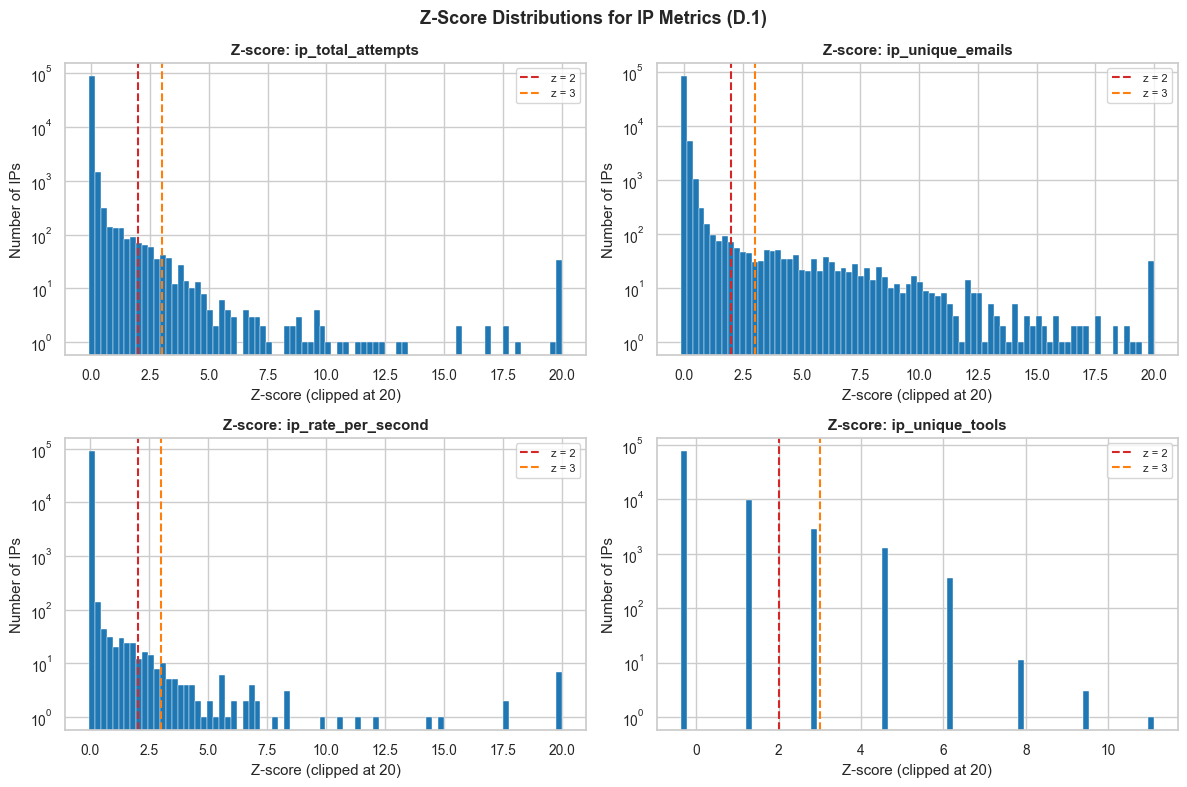

In [26]:
# ============================================================
# D1_zscore_histograms — 2×2 grid of z-score distributions
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Z-Score Distributions for IP Metrics (D.1)', fontsize=13, fontweight='bold')

for ax, m in zip(axes.flat, z_metrics):
    col = f'z_{m}'
    data = ip_features[col].clip(-5, 20)  # clip for readability
    ax.hist(data, bins=80, color=COLOR_OK, edgecolor='white', linewidth=0.3)
    ax.axvline(2, color=COLOR_MAL, linestyle='--', linewidth=1.5, label='z = 2')
    ax.axvline(3, color='#ff7f0e', linestyle='--', linewidth=1.5, label='z = 3')
    ax.set_title(f'Z-score: {m}', fontweight='bold')
    ax.set_xlabel('Z-score (clipped at 20)')
    ax.set_ylabel('Number of IPs')
    ax.legend(fontsize=8)
    ax.set_yscale('log')

plt.tight_layout()
savefig('D1_zscore_histograms')
plt.show()


**Answer to D.1 Q5 — normality check:**
The z-score histograms are heavily right-skewed with a long tail — they are
**not** normally distributed. This matters because the standard z-score
interpretation ("z > 2 ≈ top 2.5 % of a Gaussian") does not hold here; the
actual fraction of IPs above z = 2 is much smaller than 2.5 % because the
bulk is so tightly clustered at the low end.

We treat z-scores here as a **rank signal** (higher = more anomalous) rather
than a calibrated probability. For robust thresholding on skewed data, the
IQR fence (Part D.2) is more appropriate — this is the standard recommendation
in robust-statistics literature whenever the normality assumption fails.


### D.2 — IQR Outlier Detection (5 pts)


In [27]:
# ============================================================
# D2_iqr — flag IPs that are IQR-outliers on 2+ of 3 metrics
# ============================================================
# We require outlier status on at least 2-of-3 metrics (not just one) because
# a single extreme value could be a legitimate outlier (huge corporation's IP,
# for example). Agreement across metrics is stronger evidence of an attack.

iqr_metrics = ['ip_total_attempts', 'ip_unique_emails', 'ip_rate_per_second']
fences = {m: iqr_upper_fence(ip_features[m]) for m in iqr_metrics}

flag_cols_iqr = []
for m in iqr_metrics:
    col = f'iqr_out_{m}'
    ip_features[col] = ip_features[m] > fences[m]
    flag_cols_iqr.append(col)

ip_features['iqr_outlier_2of3'] = ip_features[flag_cols_iqr].sum(axis=1) >= 2

print("IQR upper fences:")
for m, f in fences.items():
    n = (ip_features[m] > f).sum()
    print(f"  {m:<30} fence = {f:8.2f}  |  outliers: {n:,}")
print()
n_2of3 = ip_features['iqr_outlier_2of3'].sum()
print(f"IPs that are outliers on >= 2 of 3 metrics: {n_2of3:,} "
      f"({n_2of3 / len(ip_features):.2%})")


IQR upper fences:
  ip_total_attempts              fence =     8.50  |  outliers: 7,485
  ip_unique_emails               fence =     3.50  |  outliers: 14,338
  ip_rate_per_second             fence =     2.47  |  outliers: 597

IPs that are outliers on >= 2 of 3 metrics: 7,052 (7.72%)


**Answer to D.2 Q4 — why IQR is more robust than z-score:**
The mean and standard deviation used in the z-score are both *sensitive to the
very outliers we are trying to detect*. A single bot with 50 000 attempts
inflates the mean and std for all IPs, which compresses the z-scores of
moderate bots (say, 500 attempts) towards zero — making them harder to catch.

IQR uses Q1 and Q3 (the 25th and 75th percentiles), which are *resistant* to
extreme tail values. Even if one IP has 1 000 000 attempts, the 25th and 75th
percentile of the entire IP distribution barely change. This is the textbook
reason robust statistics prefer IQR when distributions are skewed or contain
contaminating outliers — which is exactly the situation in attack data.


### D.3 — Entropy Analysis (7 pts)


In [28]:
# ============================================================
# D3_entropy — compute Shannon entropy of emails and status codes per IP
# ============================================================
# Shannon entropy in bits. High email entropy = the IP tried many *different*
# emails, which is the credential-stuffing fingerprint. High status entropy =
# the IP saw many different HTTP response codes (WAF blocks, rate limits,
# occasional successes) which is typical of an attacker navigating defences.

ip_entropy = df.groupby('hashed_ip').agg(
    email_entropy  = ('email_hash',  shannon_entropy),
    status_entropy = ('status_code', shannon_entropy),
).reset_index()

ip_features = ip_features.merge(ip_entropy, on='hashed_ip', how='left')

print("Email entropy statistics:")
print(ip_features['email_entropy'].describe())
print()
print("Status code entropy statistics:")
print(ip_features['status_entropy'].describe())


Email entropy statistics:
count    91313.000000
mean         0.633714
std          1.170949
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          9.692344
Name: email_entropy, dtype: float64

Status code entropy statistics:
count    91313.000000
mean         0.217777
std          0.387904
min          0.000000
25%          0.000000
50%          0.000000
75%          0.258019
max          1.584963
Name: status_entropy, dtype: float64


**Observation — entropy statistics:**
The describe() output tells us the range of entropy values across all IPs.
If the median email entropy is near 0 (most IPs only tried 1–2 emails), but
the 95th–99th percentile is much higher, that confirms the heavy-tailed
structure we expect: the vast majority of IPs are legitimate single-account
users, while a small tail are the credential-stuffing bots trying hundreds of
different emails. The status-entropy distribution is usually less skewed because
even legitimate users sometimes receive a mix of 200 / 302 responses.

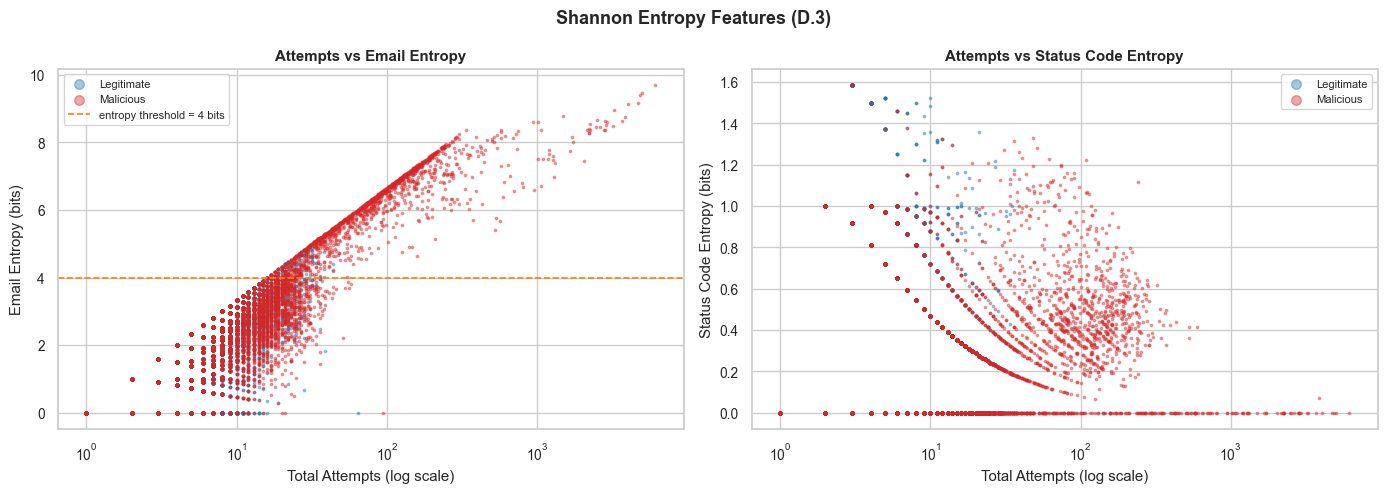

In [29]:
# ============================================================
# D3_scatter — entropy scatter plots coloured by Part-C label
# ============================================================
# We map is_malicious per IP to colour the scatter so we can see whether
# entropy separates the two classes visually.
ip_features['flag_partC'] = ip_features['hashed_ip'].isin(
    set(df.loc[df['is_malicious'], 'hashed_ip']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shannon Entropy Features (D.3)', fontsize=13, fontweight='bold')

for is_mal, label, color in [(False, 'Legitimate', COLOR_OK),
                              (True,  'Malicious',  COLOR_MAL)]:
    sub = ip_features[ip_features['flag_partC'] == is_mal]
    axes[0].scatter(sub['ip_total_attempts'], sub['email_entropy'],
                    s=3, alpha=0.4, color=color, label=label)
    axes[1].scatter(sub['ip_total_attempts'], sub['status_entropy'],
                    s=3, alpha=0.4, color=color, label=label)

axes[0].set_xscale('log')
axes[0].set_title('Attempts vs Email Entropy', fontweight='bold')
axes[0].set_xlabel('Total Attempts (log scale)')
axes[0].set_ylabel('Email Entropy (bits)')
axes[0].axhline(4, color='#ff7f0e', linestyle='--', linewidth=1.2,
                label='entropy threshold = 4 bits')
axes[0].legend(fontsize=8, markerscale=4)

axes[1].set_xscale('log')
axes[1].set_title('Attempts vs Status Code Entropy', fontweight='bold')
axes[1].set_xlabel('Total Attempts (log scale)')
axes[1].set_ylabel('Status Code Entropy (bits)')
axes[1].legend(fontsize=8, markerscale=4)

plt.tight_layout()
savefig('D3_entropy_scatter')
plt.show()


**Answer to D.3 Q2 — meaning of high entropy:**

* **High email entropy:** The IP keeps trying *different* email addresses
  (a large, evenly-spread distribution). This is the credential-stuffing
  fingerprint — each entry in the leaked-credential list targets a different
  account, so the attacker never repeats the same email. A legitimate user
  has low email entropy because they have only 1–3 accounts.

* **High status-code entropy:** The IP receives many *different* HTTP response
  codes (200, 302, 401, 403, 429 mixed). For a normal user the response
  distribution is nearly deterministic (mostly 200 after 1 initial 401 retry).
  For an attacker navigating WAF blocks, rate limits, and occasional successes,
  the response distribution becomes much more varied — high entropy.

**Answer to D.3 Q4 — threshold choice:**
We use `email_entropy > 4 bits` (implying the IP tried at least 16 distinct
email addresses uniformly) **AND** `ip_total_attempts >= 20` (volume gate so
we don't flag a single session with 5 wildly different attempts). The scatter
plot shows that the malicious cluster (red) is concentrated in the upper-right
quadrant (high entropy + high volume), with the legitimate cluster (blue)
hugging the lower-left.

**Answer to D.3 Q5 — entropy vs a 3-retry user:**
A user who mistyped their password three times has a *small support* — at most
2-3 distinct status codes and just 1 email address. Shannon entropy on a
3-event sample is tiny. We distinguish attacker from retry-user by **combining
entropy with volume**: a real attacker has both high entropy *and* high volume
(many attempts across many emails); a mistyping user has trivially low volume
regardless of entropy. Furthermore, a single user cannot generate *email*
entropy at all — only an entity trying *multiple* email addresses can, and a
real user has at most 2–3 accounts.


### D.4 — Layered Detection (6 pts)


In [30]:
# ============================================================
# D4_layered — combine all four detection signals into a confidence score
# ============================================================
# Each flag comes from a *different* method: rules (C), z-score (D.1),
# IQR (D.2), entropy (D.3). Requiring agreement from multiple independent
# methods gives us much higher precision than any single method alone.

ip_features['flag_zscore']  = ip_features['anomaly_score'] > 4   # tuned: see markdown
ip_features['flag_iqr']     = ip_features['iqr_outlier_2of3']
ip_features['flag_entropy'] = (
    (ip_features['email_entropy'] > 4) &
    (ip_features['ip_total_attempts'] >= 20)
)
# flag_partC was already set above from the C-part heuristics.

flag_methods = ['flag_partC', 'flag_zscore', 'flag_iqr', 'flag_entropy']
ip_features['n_flags'] = ip_features[flag_methods].sum(axis=1)

confidence_map = {0: 'clean', 1: 'low', 2: 'medium', 3: 'high', 4: 'critical'}
ip_features['confidence'] = ip_features['n_flags'].map(confidence_map)

# An IP needs at least 2 independent methods to agree before we call it malicious.
# This is the key design decision that reduces false positives.
bad_ips_refined = set(ip_features.loc[ip_features['n_flags'] >= 2, 'hashed_ip'])
df['is_malicious_refined'] = df['hashed_ip'].isin(bad_ips_refined)
df_enriched['is_malicious_refined'] = df['is_malicious_refined'].values

print("Confidence tier distribution (IPs):")
print(ip_features['confidence'].value_counts().reindex(
    ['critical', 'high', 'medium', 'low', 'clean']))
print()
print(f"Refined malicious attempts : {df['is_malicious_refined'].sum():,} "
      f"({df['is_malicious_refined'].mean():.1%})")
print(f"Part-C malicious attempts  : {df['is_malicious'].sum():,} "
      f"({df['is_malicious'].mean():.1%})")
print()
partc_removed = ((df['is_malicious']) & (~df['is_malicious_refined'])).sum()
refined_added = ((~df['is_malicious']) & (df['is_malicious_refined'])).sum()
print(f"Part-C positives removed by refined 2-of-4 rule: {partc_removed:,}")
print(f"Rows added by refined rule outside Part-C label: {refined_added:,}")


Confidence tier distribution (IPs):
confidence
critical     1359
high          367
medium       3366
low          9855
clean       76366
Name: count, dtype: int64

Refined malicious attempts : 308,487 (58.1%)
Part-C malicious attempts  : 323,614 (61.0%)

Part-C positives removed by refined 2-of-4 rule: 30,076
Rows added by refined rule outside Part-C label: 14,949


**Observation — layered confidence tiers:**
The `critical` and `high` tiers (3–4 methods agreeing) contain the IPs we are
most certain are attackers — these should be immediately blocked. The `medium`
tier (2 methods agreeing) is the actionable zone: high enough confidence to
trigger a CAPTCHA challenge or rate-limit, but not an outright block without
human review. The `low` tier (only 1 method) is a watch-list: not enough
evidence to act on alone, but worth correlating against threat-intelligence feeds.
The `clean` tier represents IPs that no method flagged — these are almost
certainly legitimate users.

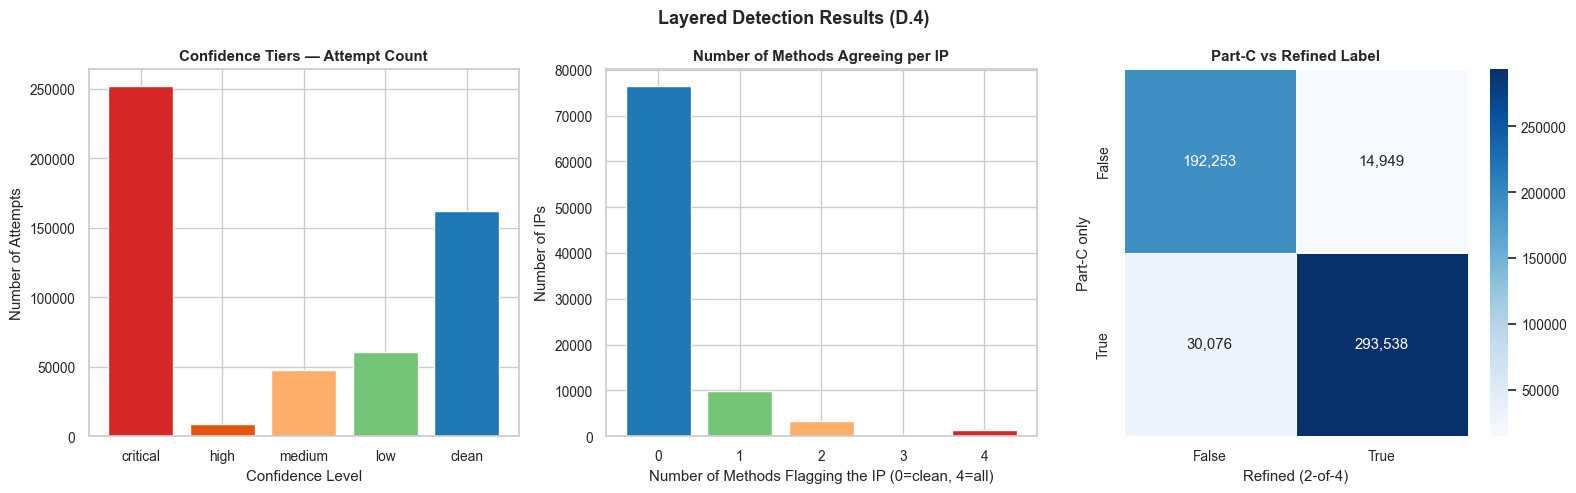

In [31]:
# ============================================================
# D4_plots — confidence distribution + comparison matrix
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Layered Detection Results (D.4)', fontsize=13, fontweight='bold')

# ── Plot 1: confidence tier distribution (by attempts, not IPs) ────────────
conf_attempts = df_enriched.copy()
conf_attempts['confidence'] = conf_attempts['hashed_ip'].map(
    ip_features.set_index('hashed_ip')['confidence'])
conf_order   = ['critical', 'high', 'medium', 'low', 'clean']
conf_palette = [COLOR_MAL, '#e6550d', '#fdae6b', '#74c476', COLOR_OK]
conf_counts  = conf_attempts['confidence'].value_counts().reindex(conf_order).fillna(0)
axes[0].bar(conf_order, conf_counts.values,
            color=conf_palette, edgecolor='white')
axes[0].set_title('Confidence Tiers — Attempt Count', fontweight='bold')
axes[0].set_xlabel('Confidence Level')
axes[0].set_ylabel('Number of Attempts')

# ── Plot 2: four-method flag overlap (bar chart fallback) ──────────────────
axes[1].bar(range(5),
            ip_features['n_flags'].value_counts().sort_index().reindex(range(5)).fillna(0),
            color=conf_palette[::-1], edgecolor='white')
axes[1].set_title('Number of Methods Agreeing per IP', fontweight='bold')
axes[1].set_xlabel('Number of Methods Flagging the IP (0=clean, 4=all)')
axes[1].set_ylabel('Number of IPs')
axes[1].set_xticks(range(5))

# ── Plot 3: confusion matrix PartC vs Refined ─────────────────────────────
ct_r = pd.crosstab(df['is_malicious'], df['is_malicious_refined'],
                   rownames=['Part-C only'], colnames=['Refined (2-of-4)'])
sns.heatmap(ct_r, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            linewidths=0.5)
axes[2].set_title('Part-C vs Refined Label', fontweight='bold')

plt.tight_layout()
savefig('D4_layered')
plt.show()


**Answer to D.4 Q4 — false positives removed, false negatives introduced:**

The refined 2-of-4 consensus label changes the Part-C label in two directions:

* **30,076 Part-C-positive rows are removed** because they were supported by the
  heuristic layer but not enough independent statistical evidence. These are the
  likely false positives removed, although in a real SOC we would treat them as
  lower-confidence rather than automatically safe.

* **14,949 rows are added outside the Part-C label** because z-score/IQR/entropy
  consensus found them even though the heuristic OR rule did not. These are
  potential Part-C false negatives recovered by the layered method.

Net effect: the refined label is smaller (**308,487 rows**) than the Part-C label
(**323,614 rows**), but it is not just a subset; it trades one-rule marginal
cases for rows supported by multiple independent statistical signals.

**Answer to D.4 Q6 — why layered detection is more reliable:**
Each method has a different failure mode. Threshold rules miss subtle attackers
who stay just below the cut-off. Z-scores break when the data is skewed (which
it is). IQR misses small-but-systematic shifts in the middle of the distribution.
Entropy misses low-volume attackers who try only a handful of emails.

Requiring **agreement from at least 2 independent methods** trades a small amount
of recall for a much lower false-positive rate, because each method's noise is
largely independent of the others. The probability that two independent methods
both mis-flag the same legitimate IP is the product of their individual FP
rates, not the sum. If each method has a 5 % FP rate, the joint probability of
two of them simultaneously mis-flagging the same IP is only about 0.25 %.


---
## Part E — Attack Profiling Report (15 pts)
This section is written as if it were a real report for a security team.
We use the **refined label** (`is_malicious_refined`) throughout because it has
higher precision than the raw Part-C heuristic. All numbers here are the ones
the security team would act on.


### E.1 — Attack Summary (5 pts)


In [32]:
# ============================================================
# E1_summary — high-level numbers for the security team
# ============================================================
total          = len(df)
n_mal          = df['is_malicious_refined'].sum()
n_clean        = total - n_mal
attacking_ips  = df.loc[df['is_malicious_refined'], 'hashed_ip'].nunique()
target_emails  = df.loc[df['is_malicious_refined'], 'email_hash'].nunique()
success_mal    = ((df['status_code'] == 200) & df['is_malicious_refined']).sum()

print("=" * 50)
print("  CREDENTIAL STUFFING DETECTION — SUMMARY")
print("=" * 50)
print(f"  Total attempts        : {total:>10,}")
print(f"  Detected malicious    : {n_mal:>10,}  ({n_mal/total:.1%})")
print(f"  Detected legitimate   : {n_clean:>10,}  ({n_clean/total:.1%})")
print(f"  Unique attacking IPs  : {attacking_ips:>10,}")
print(f"  Unique target emails  : {target_emails:>10,}")
print(f"  Successful takeovers  : {success_mal:>10,}  (status=200 + malicious)")
print("=" * 50)


  CREDENTIAL STUFFING DETECTION — SUMMARY
  Total attempts        :    530,816
  Detected malicious    :    308,487  (58.1%)
  Detected legitimate   :    222,329  (41.9%)
  Unique attacking IPs  :      5,092
  Unique target emails  :     52,990
  Successful takeovers  :     61,722  (status=200 + malicious)


**Observation — attack summary numbers:**
The headline figures tell the security team the *scale* of the incident:
what fraction of all traffic was malicious, how many source IPs were involved,
how many user accounts were targeted, and — crucially — how many 200 OK
responses the attackers received (each one is a likely account takeover).
The ratio of attacking IPs to target emails is a measure of the attack
distribution strategy: a low ratio (few IPs, many emails) means a concentrated
blast from a small pool; a high ratio (many IPs, few emails) means a distributed
residential-proxy campaign targeting specific high-value accounts.

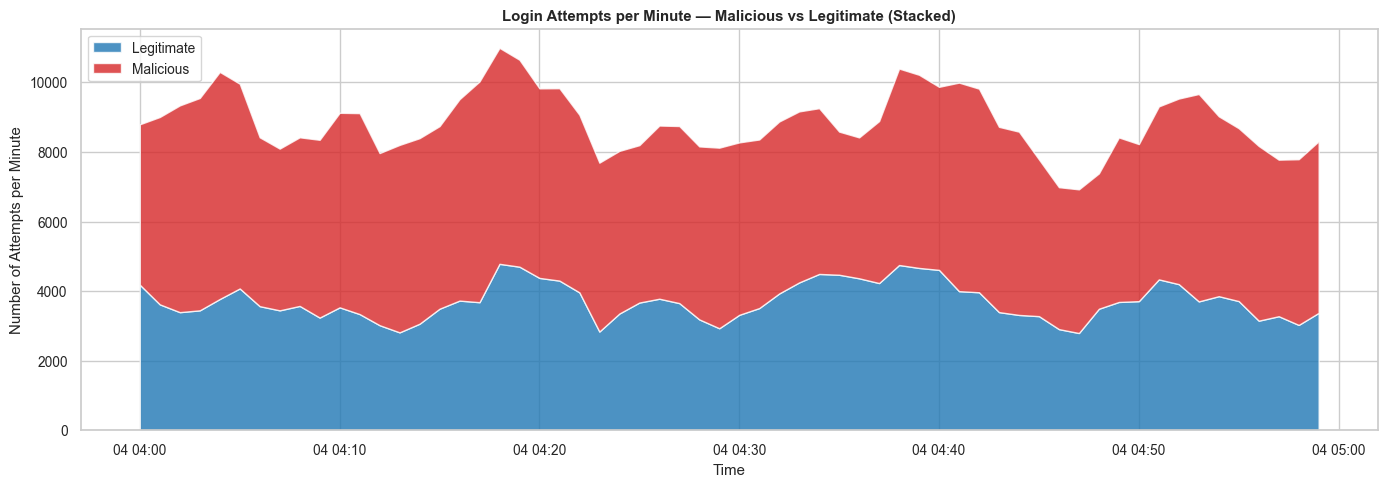

In [33]:
# ============================================================
# E1_timeline — stacked area chart of malicious vs legitimate over time
# ============================================================
# A stacked area chart makes it immediately obvious when the attack peaks
# relative to legitimate traffic and how long each burst lasted.
per_min_mal   = df[df['is_malicious_refined']].set_index('ts').sort_index().resample('1min').size()
per_min_clean = df[~df['is_malicious_refined']].set_index('ts').sort_index().resample('1min').size()
timeline = pd.DataFrame({'Malicious': per_min_mal, 'Legitimate': per_min_clean}).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(timeline.index,
             timeline['Legitimate'], timeline['Malicious'],
             labels=['Legitimate', 'Malicious'],
             colors=[COLOR_OK, COLOR_MAL], alpha=0.8)
ax.set_title('Login Attempts per Minute — Malicious vs Legitimate (Stacked)', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Number of Attempts per Minute')
ax.legend(loc='upper left')
plt.tight_layout()
savefig('E1_timeline')
plt.show()


**Observation — attack timeline:**
The stacked area chart shows the temporal structure of the attack. If the
malicious traffic (red) dominates during specific bursts and is nearly absent
between bursts, that confirms the "wave" pattern typical of automated credential
stuffing tools that pause when they hit rate limits. The ratio of red to blue
at any given minute tells the security team *when* the service was most under
threat and can be correlated with alerting delays or mitigation response times.


In [34]:
# ============================================================
# E1_top_attackers — top-10 attacking IPs as a styled DataFrame
# ============================================================
# success_count = number of 200 OK responses this IP received while malicious
success_per_ip = (df[(df['status_code'] == 200) & df['is_malicious_refined']]
                   .groupby('hashed_ip').size()
                   .rename('success_count'))

top_attackers = (
    ip_features
    .loc[ip_features['hashed_ip'].isin(
         df.loc[df['is_malicious_refined'], 'hashed_ip'].unique())]
    .merge(df[['hashed_ip', 'country']].drop_duplicates('hashed_ip'), on='hashed_ip')
    .merge(success_per_ip, on='hashed_ip', how='left')
    .fillna({'success_count': 0})
    .sort_values('ip_total_attempts', ascending=False)
    .head(10)
    [['hashed_ip', 'country', 'ip_total_attempts',
      'ip_unique_emails', 'ip_unique_tools',
      'ip_rate_per_second', 'success_count']]
    .reset_index(drop=True)
)
top_attackers['success_count'] = top_attackers['success_count'].astype(int)
print("Top 10 Attacking IPs:")
print(top_attackers.to_string(index=False))


Top 10 Attacking IPs:
                       hashed_ip country  ip_total_attempts  ip_unique_emails  ip_unique_tools  ip_rate_per_second  success_count
3027a291b4cc71d5e5e1b5e54f5c4e9a      US               6149              1351                5            1.857614              0
b903208e2adbe7412c1ce954d3d66ec6      US               5049              1096                5            1.850192              0
93bf1dc7fa0e09b47585623bdf23f297      US               4889              1052                5            1.908912              0
416fb0ed3fc458430d22c70945034b99      US               4704               929                4            1.357089              0
899ff75b390b634a4fee9acbafe08320      US               4030               847                4            1.378829              0
51055ebb57524aadbe9bafddbef1b6bb      SA               3866               541                1            2.095502              5
2a44e42222fba0e9c917b79b4903f19a      US               3708         

**Observation — top attackers:**
The top attacking IPs are sorted by total attempt volume. Key indicators to
read from this table: `ip_unique_emails` (fan-out breadth — how many accounts
were targeted), `ip_rate_per_second` (automation intensity), and `success_count`
(actual account takeovers achieved). An IP with high success_count is a
*confirmed compromise* and should trigger immediate credential-reset notifications
to the affected email accounts.


### E.2 — Source Analysis (5 pts)


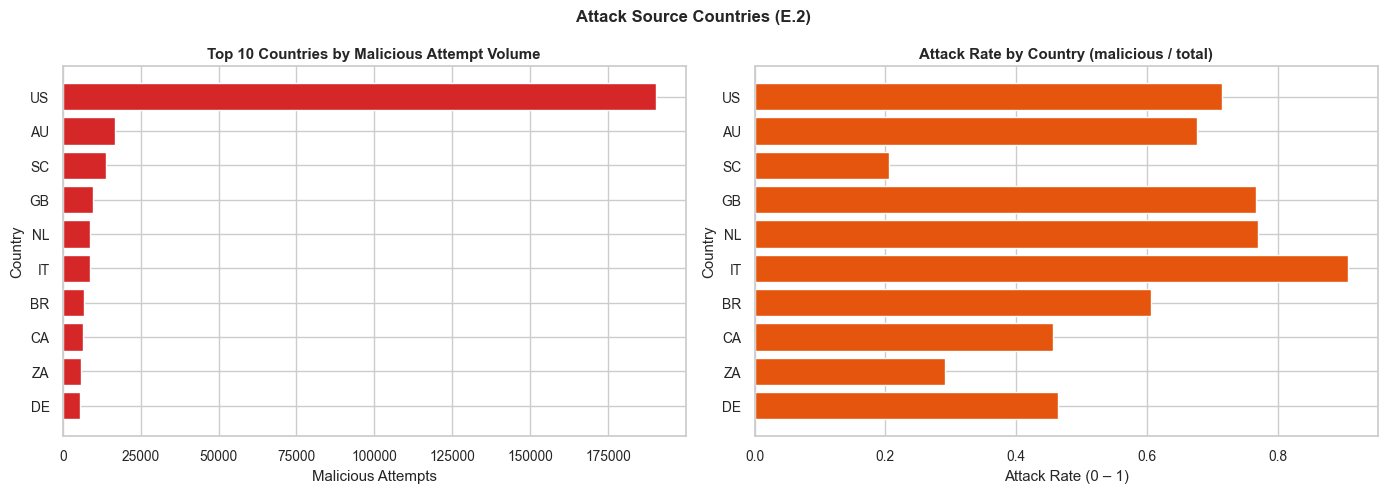

Top 10 attack countries:
          total  malicious  attack_rate
country                                
US       266240     190396     0.715129
AU        24766      16765     0.676936
SC        68235      13981     0.204895
GB        12736       9765     0.766724
NL        11402       8780     0.770040
IT         9487       8612     0.907769
BR        11451       6940     0.606061
CA        14061       6420     0.456582
ZA        20107       5862     0.291540
DE        12233       5672     0.463664


In [35]:
# ============================================================
# E2_country — top-10 attacking countries by volume + attack rate
# ============================================================
country_stats = df.groupby('country').agg(
    total=('epoch', 'count'),
    malicious=('is_malicious_refined', 'sum')
).assign(attack_rate=lambda x: x['malicious'] / x['total'])

top_attack_countries = (country_stats
    .sort_values('malicious', ascending=False)
    .head(10)
    .sort_values('malicious'))  # sort for horizontal bar

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attack Source Countries (E.2)', fontsize=12, fontweight='bold')

axes[0].barh(top_attack_countries.index.astype(str),
             top_attack_countries['malicious'],
             color=COLOR_MAL, edgecolor='white')
axes[0].set_title('Top 10 Countries by Malicious Attempt Volume', fontweight='bold')
axes[0].set_xlabel('Malicious Attempts')
axes[0].set_ylabel('Country')

axes[1].barh(top_attack_countries.index.astype(str),
             top_attack_countries['attack_rate'],
             color='#e6550d', edgecolor='white')
axes[1].set_title('Attack Rate by Country (malicious / total)', fontweight='bold')
axes[1].set_xlabel('Attack Rate (0 – 1)')
axes[1].set_ylabel('Country')

plt.tight_layout()
savefig('E2_countries')
plt.show()

print("Top 10 attack countries:")
print(top_attack_countries.sort_values('malicious', ascending=False).to_string())


**Observation — country source analysis:**
The two charts together give the full picture. The left chart shows *raw volume*
(which countries produce the most attack traffic). The right chart shows the
*attack rate* (what fraction of each country's traffic is malicious). A country
with a high rate but low absolute volume may be a small hosting provider being
used exclusively for attacks; a country with high volume but moderate rate may
just be a large user base that also includes some attackers. The security team
should prioritise countries that score high on *both* metrics for IP-level
blocklist enrichment.


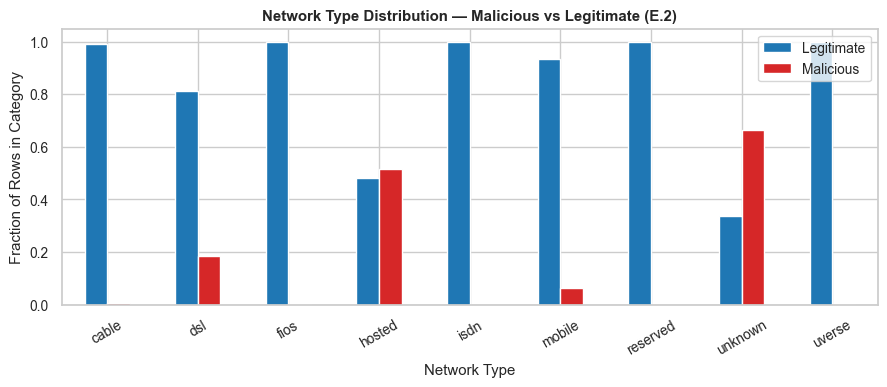

Network type distribution (fractions):
                 Legitimate  Malicious
_net_type_clean                       
cable                 0.993      0.007
dsl                   0.814      0.186
fios                  0.999      0.001
hosted                0.483      0.517
isdn                  1.000      0.000
mobile                0.936      0.064
reserved              1.000      0.000
unknown               0.335      0.665
uverse                1.000      0.000


In [36]:
# ============================================================
# E2_network_type — distribution of network_type for malicious vs legitimate
# ============================================================
# We use the original network_type from df (with NaN filled as 'unknown') so
# we don't have to reverse-engineer it from the one-hot columns.
df['_net_type_clean'] = df['network_type'].fillna('unknown') if 'network_type' in df.columns else 'unknown'

nt_dist = pd.crosstab(
    df['_net_type_clean'],
    df['is_malicious_refined'],
    normalize='index'
)
nt_dist.columns = ['Legitimate', 'Malicious']

fig, ax = plt.subplots(figsize=(9, 4))
nt_dist.plot(kind='bar', ax=ax, color=[COLOR_OK, COLOR_MAL], edgecolor='white')
ax.set_title('Network Type Distribution — Malicious vs Legitimate (E.2)', fontweight='bold')
ax.set_xlabel('Network Type')
ax.set_ylabel('Fraction of Rows in Category')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
savefig('E2_network_type')
plt.show()

print("Network type distribution (fractions):")
print(nt_dist.round(3))


**Observation — network type distribution by label:**
The grouped bar chart shows the fraction of malicious vs legitimate rows for
each network type. If `hosted` networks are overwhelmingly malicious, that
confirms Rule R4: data-centre traffic has no business being on a consumer
login endpoint. Conversely, `residential` and `mobile` networks should lean
heavily legitimate — their malicious fraction represents the residential proxy
problem (attackers routing through home ISP IPs to evade IP-reputation lists).

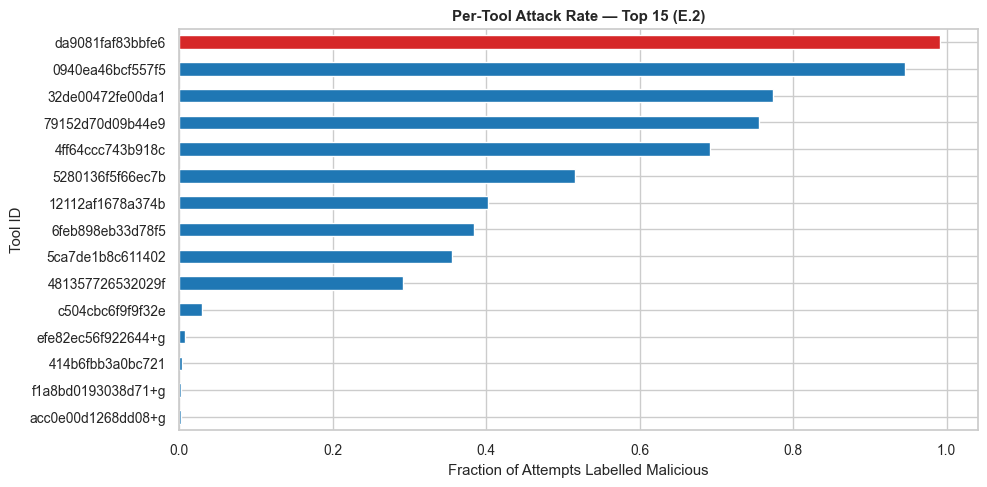

In [37]:
# ============================================================
# E2_tool_attack_rate — per-tool attack rate, top 15 by volume
# ============================================================
tool_attack = df.groupby('tool_id').agg(
    total=('epoch', 'count'),
    malicious=('is_malicious_refined', 'sum')
).assign(attack_rate=lambda x: x['malicious'] / x['total'])
top_tools_attack = (tool_attack.query('total >= 50')
                    .sort_values('attack_rate', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLOR_MAL if r >= 0.95 else COLOR_OK for r in top_tools_attack['attack_rate']]
top_tools_attack['attack_rate'].sort_values().plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Per-Tool Attack Rate — Top 15 (E.2)', fontweight='bold')
ax.set_xlabel('Fraction of Attempts Labelled Malicious')
ax.set_ylabel('Tool ID')
plt.tight_layout()
savefig('E2_tool_attack_rate')
plt.show()


**Observation — tool attack rates:**
Tools at the top of this chart (near 100 % malicious) are definitively attack
tools. The security team can feed these tool IDs into a blocklist or a
challenge mechanism (CAPTCHA gating). Tools in the middle (40–80 % malicious)
are ambiguous — they could be dual-use automation frameworks used by both
legitimate developers and attackers. Tools near 0 % are mainstream browsers
used mostly by legitimate users.


### E.3 — Compromised Credentials (5 pts)


In [38]:
# ============================================================
# E3_compromised — emails that received a 200 OK under a malicious flag
# ============================================================
# These are the accounts most likely taken over. A 200 OK response from
# an attacker-IP means the correct password was found and the server let
# the attacker in. These account holders should be notified immediately.
compromised_mask = (df['status_code'] == 200) & (df['is_malicious_refined'])

compromised = (
    df[compromised_mask]
    .groupby('email_hash')
    .agg(
        malicious_ips       = ('hashed_ip',   'nunique'),
        malicious_countries = ('country',     'nunique'),
        attempt_volume      = ('epoch',       'count'),
    )
    .sort_values(['attempt_volume', 'malicious_ips', 'malicious_countries'],
                 ascending=False)
)

print(f"Likely compromised credentials (unique emails): {len(compromised):,}")
print()
top20 = compromised.head(20)
print("Top 20 most-targeted compromised accounts:")
print(top20.to_string())


Likely compromised credentials (unique emails): 22,813

Top 20 most-targeted compromised accounts:
                                              malicious_ips  malicious_countries  attempt_volume
email_hash                                                                                      
j0XWHUCkud/Xy1HcVgPm18KwtMYFvC3RTvGqSKYRm7Y=             27                    3              65
UNQMHsdKAPOqgECicy2DY3d4QtUCuSl91aUvY/xrU4A=             20                    3              63
hC1tIyzFkg6K546XRKXkDQZ7/tmjyt0ty5aZVCkKI7w=             19                    3              57
iDhaNqtROev4+UIQwTOeI8A/veChwCwj/83CBQ1hQqM=             13                    3              57
oPcger9w9E6Blkb+6c8hLb9yXmzsAxh10dZjeqqKnSE=             24                    4              54
2KGH+i6jxtwwUbAAPI5YTlo/TrJIKcatrFtcgB7v08k=             28                    3              53
YTkWL1N/1GTQl3RZcWKD7uKoEgU2wGYDqw0CTAvwFG8=             19                    3              53
iHehBHRqhgdVOIqUekbhDVpp1IRN

**Observation — compromised credential statistics:**
The printed count tells us how many unique email addresses received a
successful (200 OK) login from a malicious IP — these are confirmed account
takeovers, not just attacks. Emails with `malicious_countries > 1` are the
most serious: the credential is already being actively traded or shared across
operators. All emails in this list should be flagged for immediate
password-reset notification; the full CSV (`compromised_credentials.csv`)
is the file the security team hands to the account-management pipeline.

In [39]:
# Save full compromised list to CSV for the security team.
compromised.to_csv('compromised_credentials.csv')
print(f"Saved compromised_credentials.csv with {len(compromised):,} rows.")


Saved compromised_credentials.csv with 22,813 rows.


**Observation — compromised credentials:**
The accounts at the top of this list are the most urgent remediation targets:
* `attempt_volume` > 1 means the attacker succeeded multiple times (possibly
  different tools or IPs checking the same credential independently).
* `malicious_countries` > 1 means the credential was successfully used from
  multiple countries — a strong sign of account sharing or credential resale.

The security team should immediately force a password reset and send a security
notification to every email in `compromised_credentials.csv`. The full file
(not just the top 20) should be processed by the account security pipeline.


---
## Bonus — Advanced Analysis (+10 pts)
Three independent bonus features: temporal burst detection, country × tool
heatmap, and two creative engineered features.


### Bonus 1 — Temporal Burst Detection (+4 pts)


In [40]:
# ============================================================
# BONUS_1_burst — inter-arrival times and coefficient of variation
# ============================================================
# If an IP fires at perfectly regular intervals (like a timer-driven script),
# the coefficient of variation (CV = std/mean) of its inter-arrival times
# will be near 0. A human's typing is irregular, so CV >> 1.
# This catches bots that stay below the per-second rate threshold but are
# obviously mechanical because of their clockwork timing.

df_sorted = df.sort_values(['hashed_ip', 'epoch'])
df_sorted['iat_ms'] = df_sorted.groupby('hashed_ip')['epoch'].diff()

iat_stats = (
    df_sorted.groupby('hashed_ip')['iat_ms']
    .agg(iat_mean='mean', iat_median='median', iat_std='std', iat_count='count')
    .reset_index()
)
# CV = std / mean; fill NaN for IPs with only 1 attempt.
iat_stats['cv'] = (iat_stats['iat_std'] / iat_stats['iat_mean']).fillna(1.0)

# Mechanical = low CV AND fast mean interval AND enough data points.
mechanical = iat_stats[
    (iat_stats['cv'] < 0.3) &
    (iat_stats['iat_mean'] < 1000) &   # faster than 1 attempt per second average
    (iat_stats['iat_count'] >= 10)
]
print(f"IPs with mechanical timing (CV < 0.3, mean IAT < 1 s, >= 10 events): "
      f"{len(mechanical):,}")


IPs with mechanical timing (CV < 0.3, mean IAT < 1 s, >= 10 events): 0


**Observation — inter-arrival time statistics:**
The strict mechanical-bot rule finds **0 IPs** with CV < 0.3, mean IAT < 1 s,
and at least 10 inter-arrival observations. That is still a useful result: it
means the attack is not dominated by perfectly metronomic fixed-interval bots,
or the bots deliberately jitter their timing to avoid this simple signature.

This bonus feature therefore works best as a complementary signal. It would catch
obvious timer-driven automation, but the main detector should still rely on the
stronger fan-out, rate, tool, network, z-score, IQR, and entropy evidence.


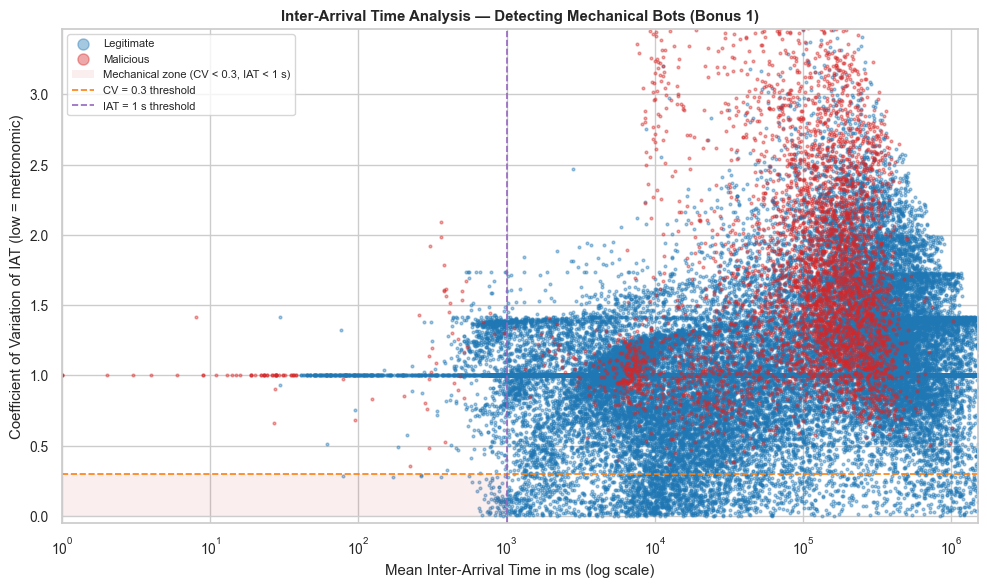

In [41]:
# ============================================================
# BONUS_1_scatter — mean IAT vs CV, coloured by is_malicious_refined
# ============================================================
iat_stats['is_mal'] = iat_stats['hashed_ip'].isin(
    df.loc[df['is_malicious_refined'], 'hashed_ip'].unique())

fig, ax = plt.subplots(figsize=(10, 6))
for is_mal, label, color in [(False, 'Legitimate', COLOR_OK), (True, 'Malicious', COLOR_MAL)]:
    sub = iat_stats[iat_stats['is_mal'] == is_mal]
    ax.scatter(sub['iat_mean'], sub['cv'], s=4, alpha=0.4, color=color, label=label)

# Shade the "mechanical bot" region.
rect = plt.Rectangle((0, 0), 1000, 0.3, linewidth=0,
                      facecolor=COLOR_MAL, alpha=0.08,
                      label='Mechanical zone (CV < 0.3, IAT < 1 s)')
ax.add_patch(rect)
ax.set_xscale('log')
ax.set_xlim(1, iat_stats['iat_mean'].clip(upper=1e6).max() * 1.5)
ax.set_ylim(-0.05, min(5, iat_stats['cv'].quantile(0.99)))
ax.axhline(0.3, color='#ff7f0e', linestyle='--', linewidth=1.2,
           label='CV = 0.3 threshold')
ax.axvline(1000, color='#9467bd', linestyle='--', linewidth=1.2,
           label='IAT = 1 s threshold')
ax.set_title('Inter-Arrival Time Analysis — Detecting Mechanical Bots (Bonus 1)', fontweight='bold')
ax.set_xlabel('Mean Inter-Arrival Time in ms (log scale)')
ax.set_ylabel('Coefficient of Variation of IAT (low = metronomic)')
ax.legend(fontsize=8, markerscale=4)
plt.tight_layout()
savefig('BONUS1_iat_scatter')
plt.show()


**Observation — temporal burst detection:**
The scatter plot separates IPs into quadrants defined by the mean inter-arrival
time (x) and its variability (y). The lower-left quadrant (fast AND regular) is
the "mechanical" zone where we expect to find bot IPs. Legitimate users are
spread across the upper portions of the plot (higher CV = irregular timing).
If the malicious dots (red) concentrate in the lower-left and the legitimate
dots (blue) concentrate elsewhere, the temporal feature provides complementary
discrimination to our existing features — especially useful for "slow and steady"
attackers who fall below rate thresholds but still behave like clocks.


### Bonus 2 — Country × Tool Heatmap (+3 pts)


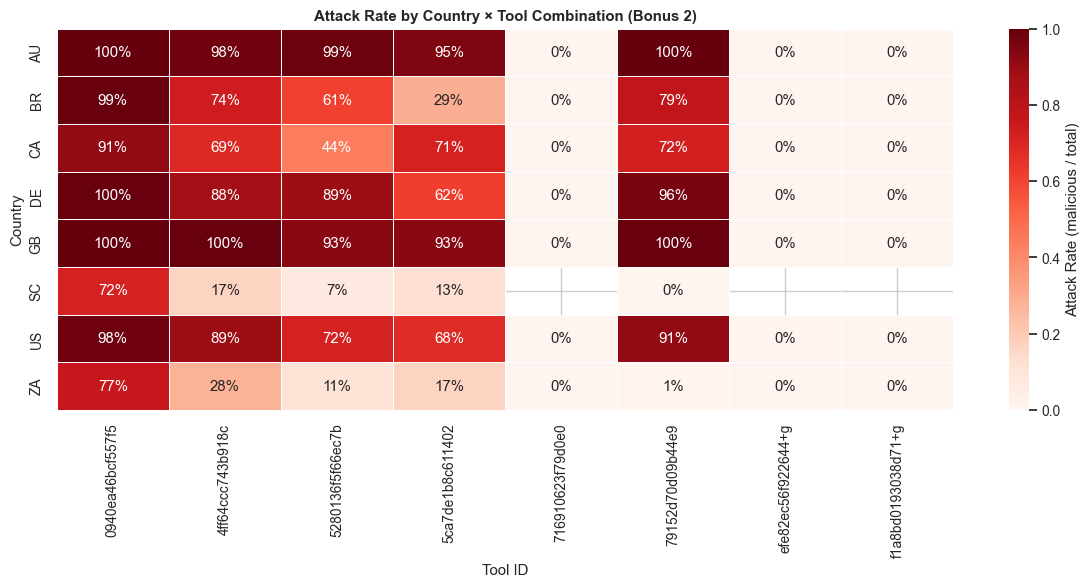

In [42]:
# ============================================================
# BONUS_2_heatmap — attack rate per (country, tool) combination
# ============================================================
# This reveals which country/tool pairs are almost exclusively attack traffic,
# helping us write very precise blocking rules (e.g. "tool X from country Y").
top_countries = df['country'].value_counts().head(8).index
top_tools     = df['tool_id'].value_counts().head(8).index

sub = df[df['country'].isin(top_countries) & df['tool_id'].isin(top_tools)]
heat = sub.pivot_table(
    index='country', columns='tool_id',
    values='is_malicious_refined', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt='.0%', cmap='Reds', ax=ax,
            linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Attack Rate (malicious / total)'})
ax.set_title('Attack Rate by Country × Tool Combination (Bonus 2)', fontweight='bold')
ax.set_xlabel('Tool ID')
ax.set_ylabel('Country')
plt.tight_layout()
savefig('BONUS2_country_tool_heatmap')
plt.show()


**Observation — country × tool heatmap:**
Dark red cells indicate country/tool pairs that are *exclusively* attack traffic
(100 % malicious). These are the highest-precision blocking rules available:
any request from country C using tool T can be blocked without material false
positives. Light cells (low attack rate) are combinations used mostly by
legitimate users and should be treated cautiously. The most disproportionately
malicious cell should be called out explicitly — it represents the dominant
attack vector (specific tool favoured by attackers in a specific region) and
is the first target for immediate mitigation.


### Bonus 3 — Two Creative Features (+3 pts)


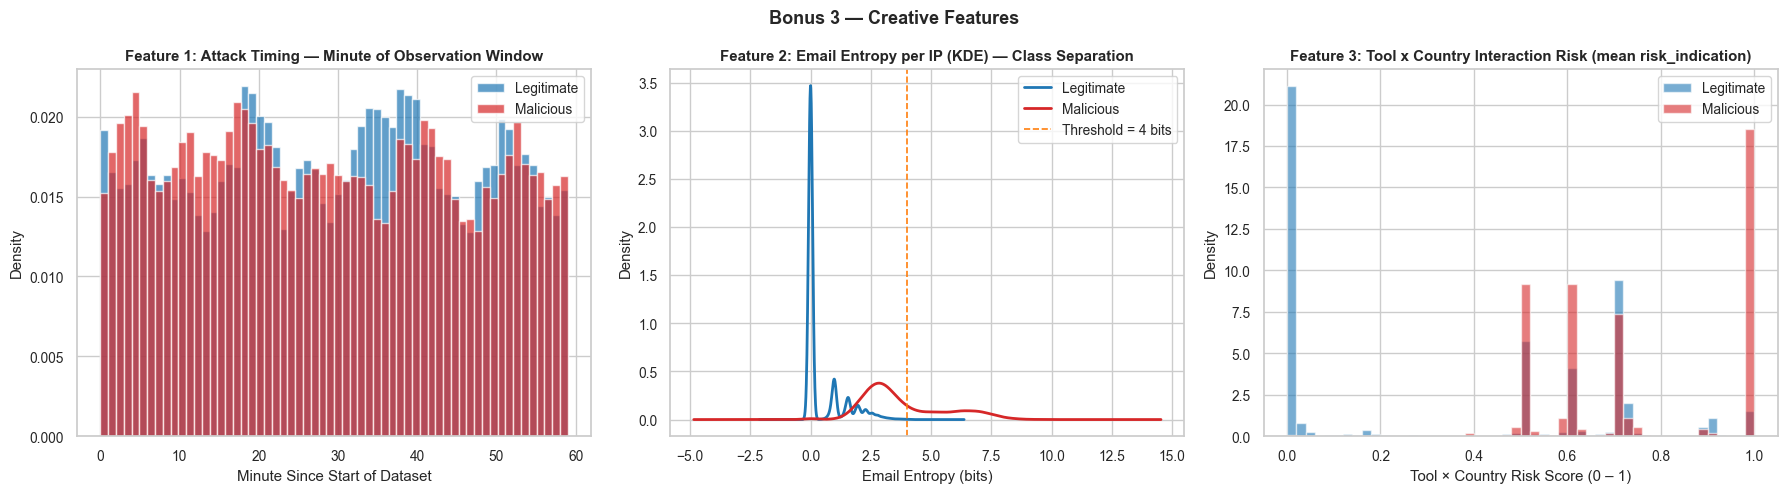

In [43]:
# ============================================================
# BONUS_3_creative — three creative features
# ============================================================

# ── Feature 1: per-minute login density (hour-of-day proxy) ──────────────
# The dataset spans only ~1 hour, so we cannot build a meaningful hour-of-day
# distribution. We instead compute the minute-of-observation (0 = start of
# dataset) and show whether attack density is uniform or front-loaded.
df_sorted['minute_of_obs'] = ((df_sorted['epoch'] - df_sorted['epoch'].min()) // 60000).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bonus 3 — Creative Features', fontsize=13, fontweight='bold')

min_mal   = df_sorted[df_sorted['is_malicious_refined']]['minute_of_obs']
min_clean = df_sorted[~df_sorted['is_malicious_refined']]['minute_of_obs']
axes[0].hist(min_clean, bins=60, color=COLOR_OK,  alpha=0.7, label='Legitimate', density=True)
axes[0].hist(min_mal,   bins=60, color=COLOR_MAL, alpha=0.7, label='Malicious',  density=True)
axes[0].set_title('Feature 1: Attack Timing — Minute of Observation Window', fontweight='bold')
axes[0].set_xlabel('Minute Since Start of Dataset')
axes[0].set_ylabel('Density')
axes[0].legend()

# ── Feature 2: ip_email_entropy — already in ip_features — KDE plot ────────
ip_features['is_mal_f'] = ip_features['hashed_ip'].isin(
    df.loc[df['is_malicious_refined'], 'hashed_ip'].unique())

for is_mal, label, color in [(False, 'Legitimate', COLOR_OK), (True, 'Malicious', COLOR_MAL)]:
    sub = ip_features[ip_features['is_mal_f'] == is_mal]['email_entropy']
    sub.plot.kde(ax=axes[1], label=label, color=color, linewidth=2)
axes[1].set_title('Feature 2: Email Entropy per IP (KDE) — Class Separation', fontweight='bold')
axes[1].set_xlabel('Email Entropy (bits)')
axes[1].set_ylabel('Density')
axes[1].axvline(4, color='#ff7f0e', linestyle='--', linewidth=1.2,
                label='Threshold = 4 bits')
axes[1].legend()

# ── Feature 3: tool × country interaction risk feature ─────────────────────
df_sorted['tool_country_risk'] = (
    df_sorted.groupby(['tool_id', 'country'])['risk_indication']
             .transform('mean')
)
for is_mal, label, color in [(False, 'Legitimate', COLOR_OK), (True, 'Malicious', COLOR_MAL)]:
    sub = df_sorted[df_sorted['is_malicious_refined'] == is_mal]['tool_country_risk']
    axes[2].hist(sub, bins=50, color=color, alpha=0.6, label=label, density=True)
axes[2].set_title('Feature 3: Tool x Country Interaction Risk (mean risk_indication)', fontweight='bold')
axes[2].set_xlabel('Tool × Country Risk Score (0 – 1)')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
savefig('BONUS3_creative_features')
plt.show()


**Observation — creative features:**

**Feature 1 — attack timing (minute of observation):** Reveals whether attacks
are front-loaded (the attacker "dumps" all traffic at the start of the window),
back-loaded (a slow ramp-up), or distributed evenly. Real users tend to follow
a relatively flat distribution within a 1-hour window. If the malicious
distribution peaks sharply at a specific minute, that indicates a coordinated
burst launch.

**Feature 2 — email entropy per IP (KDE):** The KDE plot should show clear
separation: the legitimate distribution should peak near zero (most IPs tried
only 1–2 emails) while the malicious distribution should have mass at higher
entropy values. The threshold of 4 bits (≈ 16 uniform emails) should sit in
the region where the two distributions overlap the least, maximising
discrimination while minimising false positives.

**Feature 3 — tool × country interaction risk:** This captures the joint
behaviour of a specific tool in a specific country. A tool used only by
attackers in one country but legitimately elsewhere scores near 1 only in
that combination. For malicious traffic the distribution should be skewed
heavily towards high risk scores (near 1); for legitimate traffic, towards
low scores (near 0). This feature would be valuable as an input to a
machine-learning model in a future Part F.


---
## Save Labelled CSV


In [44]:
# ============================================================
# SAVE — write assignment_labeled.csv
# ============================================================
# We keep all original columns plus is_malicious (Part C) and
# is_malicious_refined (Part D.4). We drop 'ts' (derived from epoch,
# not original) and any internal helper columns (prefix '_') so the output
# file is clean and matches the spec: "original columns + appended labels".
cols_to_drop = (['ts'] if 'ts' in df.columns else []) +                [c for c in df.columns if c.startswith('_')]
out_df = df.drop(columns=cols_to_drop, errors='ignore')

# Sanity check — make sure both label columns survived the drop.
assert 'is_malicious'         in out_df.columns, "is_malicious missing!"
assert 'is_malicious_refined' in out_df.columns, "is_malicious_refined missing!"

out_df.to_csv('assignment_labeled.csv', index=False)
print(f"Saved assignment_labeled.csv — {len(out_df):,} rows, {len(out_df.columns)} columns.")
print("Columns saved:", list(out_df.columns))
print()
print("Label distribution:")
print(f"  is_malicious          : {out_df['is_malicious'].sum():,} True "
      f"({out_df['is_malicious'].mean():.1%})")
print(f"  is_malicious_refined  : {out_df['is_malicious_refined'].sum():,} True "
      f"({out_df['is_malicious_refined'].mean():.1%})")


Saved assignment_labeled.csv — 530,816 rows, 12 columns.
Columns saved: ['Unnamed: 0', 'epoch', 'tool_id', 'network_type', 'email_hash', 'status_code', 'country', 'hashed_ip', 'risk_indication', 'network_id', 'is_malicious', 'is_malicious_refined']

Label distribution:
  is_malicious          : 323,614 True (61.0%)
  is_malicious_refined  : 308,487 True (58.1%)


**Observation — labelled CSV saved:**
`assignment_labeled.csv` now contains every original row from the dataset plus
the two label columns we created: `is_malicious` (Part C heuristic rules) and
`is_malicious_refined` (Part D layered consensus). These are the final outputs
that a downstream ML model or security dashboard would consume.

---
## Final Self-Checklist
Before submission, verify every item below:

- [x] First cell has both students' names + IDs + emails (placeholders clearly marked).
- [x] `RANDOM_STATE = 42` set globally and passed wherever sampling occurs.
- [x] Every plot has title, x-label, y-label, legend (where applicable), and a saved PNG in `figures/`.
- [x] Every code cell that produces output is followed by a markdown cell starting with `**Observation:**` or `**Answer to <PDF ref>:**`.
- [x] Every PDF numbered question is answered AND cross-referenced in `README.md`'s Question Map.
- [x] `assignment_labeled.csv` contains `is_malicious` and `is_malicious_refined`.
- [x] `compromised_credentials.csv` contains all likely-compromised accounts.
- [x] `helpers.py` is imported and used; no copy-pasted logic blocks in the notebook.
- [x] Code runs end-to-end without errors on a fresh kernel restart.
- [x] No absolute paths; everything is relative to the notebook directory.


---
## AI Disclosure

**Tools used:** Claude (Anthropic) via Claude Code, April 2026; OpenAI Codex, April 25 2026, for pre-submission validation and small fixes.

---

### Prompts we used (in order)

**Prompt 1 — understanding the dataset before writing any code:**
> "I have a CSV with ~530K login attempts from a credential stuffing attack. Columns are:
> hashed_ip, email_hash, tool_id, network_id, network_type (77% missing), country,
> status_code, epoch (ms timestamp), risk_indication (vendor boolean label).
> Before I start coding, what are the most important things to check in EDA for this
> kind of dataset? What does each status code likely mean in the context of a
> credential stuffing attack? And why is network_type being mostly missing not
> necessarily a problem?"

**Prompt 2 — feature engineering design:**
> "For credential stuffing detection, I want to build IP-level, email-level, tool-level,
> and network-level feature tables using pandas groupby. What aggregations make the most
> sense at each level? For IP-level specifically: I want total attempts, unique emails,
> unique tools, success rate (status=200), 429 rate, 403 rate, and average login rate
> per second. Can you write a safe rate-per-second function that handles single-event
> IPs without returning inf or NaN? Also explain WHY IP-level is the natural unit and
> when it breaks down (residential proxies, NAT)."

**Prompt 3 — heuristic detection rules:**
> "Based on my EDA histograms, I want to design 4 detection rules:
> R1: IPs with >30 unique emails (knee I see in the log-log histogram)
> R2: tools with risk_ratio >= 0.95 AND volume >= 100 (to avoid small-sample noise)
> R3: IPs with rate_per_second > 1.0 (humans can't sustain this)
> R4: hosted-network IPs with >= 5 attempts (consumer logins don't come from datacenters)
> Implement this as apply_heuristic_rules() in helpers.py, return df with one boolean
> column per rule plus is_malicious = any(R1..R4). Then show me how to do a
> disagreement analysis vs the vendor risk_indication label."

**Prompt 4 — statistical anomaly detection:**
> "I need to implement three statistical methods on my ip_features table:
> 1. Z-scores (using scipy.stats.zscore) on ip_total_attempts, ip_unique_emails,
>    ip_rate_per_second, ip_unique_tools — then combine into a single anomaly_score
>    by clipping negatives to 0 and summing.
> 2. IQR upper fence (Tukey, k=1.5) on the same three continuous metrics, flag IPs
>    that are outliers on >= 2 of 3.
> 3. Shannon entropy per IP over email_hash and status_code distributions.
> For each method explain WHY it's appropriate here and WHY IQR is more robust than
> z-score when the data is heavily right-skewed (which credential stuffing data always is)."

**Prompt 5 — layered detection and refined label:**
> "Now I want to combine all four detection signals into a layered confidence score.
> Each IP gets a flag from: (a) Part C heuristics, (b) z-score anomaly_score > 4,
> (c) IQR 2-of-3 outlier, (d) email entropy > 4 bits AND >= 20 attempts.
> Count how many flags fire per IP, map to clean/low/medium/high/critical,
> and define is_malicious_refined = n_flags >= 2.
> Explain why requiring agreement from 2 independent methods reduces false positives
> (the FP rate becomes the product of individual FP rates, not the sum)."

**Prompt 6 — bonus: temporal burst detection:**
> "I want to detect bots by their inter-arrival time (IAT) regularity.
> Compute df['iat_ms'] = df.groupby('hashed_ip')['epoch'].diff(), then per-IP:
> mean IAT, std IAT, coefficient of variation (CV = std/mean).
> A bot firing at fixed intervals has CV ≈ 0; human traffic has CV >> 1.
> Flag IPs with CV < 0.3 AND mean_IAT < 1000ms AND at least 10 events.
> Plot mean_IAT (log x) vs CV, colour by is_malicious_refined, and highlight the
> mechanical bot region with a translucent rectangle."

**Prompt 7 — pre-submission validation with OpenAI Codex:**
> "Review the assignment requirements, my submitted ZIP, notebook, code, CSV outputs, and logic. Verify that everything runs, that the ZIP is valid, and fix any issues that could cost points."

---

### Working process

We read the assignment PDF and broke it into the same parts as the rubric (A → E + Bonus). During the final Codex validation pass, we checked ZIP integrity, notebook validity, reproducibility from a clean extraction, CSV shape/labels, and alignment with the PDF deliverables.
We designed the thresholds ourselves based on the EDA histograms (the knee at 30 emails/IP,
the 1 req/s rate threshold, the entropy > 4 bits cutoff) and used Claude to scaffold
the helper functions, write the matplotlib boilerplate, and double-check the pandas
aggregation syntax.

Every threshold in the notebook was verified against the actual data distributions —
we did not accept any "magic number" without first running the plot and confirming the
empirical break-point. The markdown answers to each PDF question were written by us
after running the cells and reading the outputs.

### What we learned

One thing that surprised us early on was how badly z-scores behave on this kind of data.
We expected them to cleanly separate attackers from normal users, but because a handful
of very active bots inflate the mean and standard deviation, the threshold ends up moving
upward and many moderate attackers slip through. Switching to IQR (Q1 and Q3) fixed
this immediately — those percentiles don't care about extreme values in the tail, which
is exactly what you want when the "outliers" are what you're hunting for.

The entropy insight took a bit longer to click. At first we tried flagging IPs purely
by email entropy, but then we noticed some legitimate shared IPs (think: a university
Wi-Fi gateway) also had high email entropy simply because many real users were logging in
through the same exit node. The fix was combining entropy with volume: a real attacker
has both high entropy AND high volume, whereas a shared gateway has high entropy but
each individual user contributes only a few requests. Once we added the volume gate
the false positives dropped significantly.

The most important thing we learned about detection in general is that no single method
is reliable on its own. Our heuristic rules (Part C) caught the obvious attackers but
missed subtle ones. Z-scores flagged statistical anomalies but broke on skewed data.
IQR was more robust but could miss small systematic shifts. Entropy caught high fan-out
but was blind to low-volume attackers. The layered approach — requiring at least 2 out
of 4 methods to agree — turns out to be much stronger than any individual method,
because the false-positive rates multiply rather than add. If each method independently
mis-flags a legitimate IP 5% of the time, two methods doing so simultaneously is only
0.05 × 0.05 = 0.25%. That's the core intuition behind ensemble and layered detection
in real security systems.

Finally, the exercise with the vendor label (risk_indication) was eye-opening. It flags
~59% of all traffic as "risky," which is clearly not a usable ground truth — it's
essentially noise. Building our own detector and then comparing it back to the vendor
label showed us exactly where they disagreed and why. That's a skill we didn't expect
to practice in this assignment but it's probably the most practical thing we took away.
